# Route Analysis Notebook

This notebook is the main working document for the route analysis. The goal is to keep reasoning, data preparation, plots, tables, and interpretation together in one place.

## Scope in This Notebook

- Section 6.3: **Prevalence of Economic Outliers**
- Section 6.4: **Economic Impact of Outlier Removal**
- Scope: `APR Profil = O18 Omdeler` and `Week Profil = Gns. Oms`
- Data source: `./data/route_analysis_dataset.csv`

The notebook is designed for exploratory analysis first. If we later need report-ready exports, we can add those selectively.

In [279]:
required_packages <- c("dplyr", "ggplot2", "readr", "scales")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]

if (length(missing_packages) > 0) {
  stop(
    paste(
      "Missing R packages:",
      paste(missing_packages, collapse = ", "),
      "\nInstall them and run the notebook again."
    ),
    call. = FALSE
  )
}

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(readr)
  library(scales)
})
data_path <- "./data/route_analysis_dataset.csv"

## Data Preparation

We load the flattened route dataset and prepare the variables needed for the descriptive analysis in Sections 6.3 and 6.4.

In [280]:
all_analysis_data <- read_csv(data_path, show_col_types = FALSE) %>%
  transmute(
    route_id = as.character(`Rute ID`),
    apr_profile = trimws(`APR Profil`),
    week_profile = trimws(`Week Profil`),
    transportform = factor(tolower(`Transportform (profile > profile)`), levels = c("car", "bike", "foot")),
    problem_type = factor(problem_type, levels = c("HPP", "TSP")),
    type = factor(Type, levels = c("Type 1", "Type 2")),
    original_addresses = `Antal enheder (len(R_original))`,
    removed_outliers = `Significant Outliers`,
    length_org = `Length Org`,
    length_opt = `Length Opt`,
    revenue_org = `Revenue (Org)`,
    revenue_opt = `Revenue (Opt)`,
    cost_org = `Cost (Org)`,
    cost_opt = `Cost (Opt)`,
    db_org = `Contribution Margin (Org)`,
    db_opt = `Contribution Margin (Opt)`,
    outlier_set_string = `Set of Significant Outliers`
  ) %>%
  mutate(
    apr_profile = factor(apr_profile, levels = c("SE Omdeler", "O18 Omdeler", "U18 Omdeler")),
    week_profile = factor(week_profile, levels = c("Gns. Oms", "U36", "U37", "U38", "U39")),
    has_outliers = removed_outliers > 0,
    removed_share = if_else(original_addresses > 0, removed_outliers / original_addresses, NA_real_),
    length_change = length_opt - length_org,
    delta_revenue = revenue_opt - revenue_org,
    delta_cost = cost_opt - cost_org,
    delta_db = db_opt - db_org,
    revenue_lost = revenue_org - revenue_opt,
    cost_saved = cost_org - cost_opt,
    relative_db_improvement = if_else(abs(db_org) > 1e-9, delta_db / db_org, NA_real_),
    route_segment = case_when(
      problem_type == "HPP" & transportform == "car" ~ "HPP / Car",
      problem_type == "TSP" & transportform == "foot" ~ "TSP / Foot",
      TRUE ~ paste(problem_type, "/", transportform)
    ),
    route_segment = factor(route_segment, levels = c("HPP / Car", "TSP / Foot"))
  )

analysis_data <- all_analysis_data %>%
  filter(apr_profile == "O18 Omdeler", week_profile == "Gns. Oms")

apr_sensitivity_data <- all_analysis_data %>%
  filter(
    week_profile == "Gns. Oms",
    apr_profile %in% c("SE Omdeler", "O18 Omdeler", "U18 Omdeler")
  )

week_sensitivity_data <- all_analysis_data %>%
  filter(
    apr_profile == "O18 Omdeler",
    week_profile %in% c("Gns. Oms", "U36", "U37", "U38", "U39")
  )

observed_week_sensitivity_data <- week_sensitivity_data %>%
  filter(week_profile %in% c("U36", "U37", "U38", "U39"))

if (nrow(analysis_data) == 0) {
  stop("No observations found for APR profile 'O18 Omdeler' and week profile 'Gns. Oms'.", call. = FALSE)
}

if (nrow(apr_sensitivity_data) == 0) {
  stop("No observations found for the APR sensitivity comparison.", call. = FALSE)
}

if (nrow(week_sensitivity_data) == 0) {
  stop("No observations found for the week-profile sensitivity comparison.", call. = FALSE)
}

head(analysis_data)



route_id,apr_profile,week_profile,transportform,problem_type,type,original_addresses,removed_outliers,length_org,length_opt,⋯,has_outliers,removed_share,length_change,delta_revenue,delta_cost,delta_db,revenue_lost,cost_saved,relative_db_improvement,route_segment
<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
37000001,O18 Omdeler,Gns. Oms,foot,TSP,Type 1,152,4,6073.6,5340.7,⋯,TRUE,0.026315789,-732.9,-13.87,-20.81,6.93686,13.87,20.81,0.009525582,TSP / Foot
37000001,O18 Omdeler,Gns. Oms,foot,TSP,Type 2,152,2,4935.6,4450.3,⋯,TRUE,0.013157895,-485.3,-7.62,-13.78,6.15502,7.62,13.78,0.008092812,TSP / Foot
37000002,O18 Omdeler,Gns. Oms,foot,TSP,Type 1,177,3,7153.3,5474.1,⋯,TRUE,0.016949153,-1679.2,-20.46,-47.70,27.22178,20.46,47.70,0.034012078,TSP / Foot
37000002,O18 Omdeler,Gns. Oms,foot,TSP,Type 2,177,3,5152.4,4251.1,⋯,TRUE,0.016949153,-901.3,-20.46,-25.60,5.12942,20.46,25.60,0.005984051,TSP / Foot
37000003,O18 Omdeler,Gns. Oms,foot,TSP,Type 1,110,3,4948.0,4271.5,⋯,TRUE,0.027272727,-676.5,-13.57,-19.21,5.64510,13.57,19.21,0.012116502,TSP / Foot
37000003,O18 Omdeler,Gns. Oms,foot,TSP,Type 2,110,1,4360.4,4254.1,⋯,TRUE,0.009090909,-106.3,-1.12,-3.02,1.90142,1.12,3.02,0.003940035,TSP / Foot


In [281]:
summarise_route_metric <- function(data, value_col, metric_label) {
  data %>%
    group_by(type, problem_type) %>%
    summarise(
      metric = metric_label,
      mean = mean({{ value_col }}, na.rm = TRUE),
      median = median({{ value_col }}, na.rm = TRUE),
      q25 = quantile({{ value_col }}, 0.25, na.rm = TRUE),
      q75 = quantile({{ value_col }}, 0.75, na.rm = TRUE),
      .groups = "drop"
    )
}

metric_order <- c("Revenue", "Cost", "Contribution Margin / DB", "Route length/time")

## 6.3 Prevalence of Economic Outliers

**Question:** How prevalent are economic outliers?

In [282]:
max_outlier_count <- max(analysis_data$removed_outliers, na.rm = TRUE)

outlier_count_distribution_table <- expand.grid(
  type = levels(analysis_data$type),
  problem_type = levels(analysis_data$problem_type),
  removed_outliers = 0:max_outlier_count,
  KEEP.OUT.ATTRS = FALSE,
  stringsAsFactors = FALSE
) %>%
  left_join(
    analysis_data %>%
      count(type, problem_type, removed_outliers, name = "route_profiles"),
    by = c("type", "problem_type", "removed_outliers")
  ) %>%
  mutate(
    route_profiles = coalesce(route_profiles, 0L),
    type = factor(type, levels = levels(analysis_data$type)),
    problem_type = factor(problem_type, levels = levels(analysis_data$problem_type))
  ) %>%
  group_by(type, problem_type) %>%
  mutate(share_of_routes = route_profiles / sum(route_profiles)) %>%
  ungroup()

outlier_address_summary_table <- analysis_data %>%
  group_by(type, problem_type) %>%
  summarise(
    route_profiles = n(),
    outlier_addresses = sum(removed_outliers, na.rm = TRUE),
    total_addresses = sum(original_addresses, na.rm = TRUE),
    share_of_all_addresses = outlier_addresses / total_addresses,
    mean_removed_share = mean(removed_share, na.rm = TRUE),
    .groups = "drop"
  )

### Quick Data Overview

In [283]:
analysis_data %>%
  summarise(
    observations = n(),
    unique_route_profiles = n_distinct(paste(route_id, week_profile, type)),
    share_with_outliers = mean(has_outliers)
  )

analysis_data %>%
  count(type)

analysis_data %>%
  count(problem_type, transportform)

observations,unique_route_profiles,share_with_outliers
<int>,<int>,<dbl>
280,280,0.8178571


type,n
<fct>,<int>
Type 1,140
Type 2,140


problem_type,transportform,n
<fct>,<fct>,<int>
HPP,car,70
TSP,foot,210


The current analysis subset (`O18 Omdeler`, `Gns. Oms`) contains `HPP / Car` and `TSP / Foot`.

### Plot 1: Number of Significant Outliers per Route

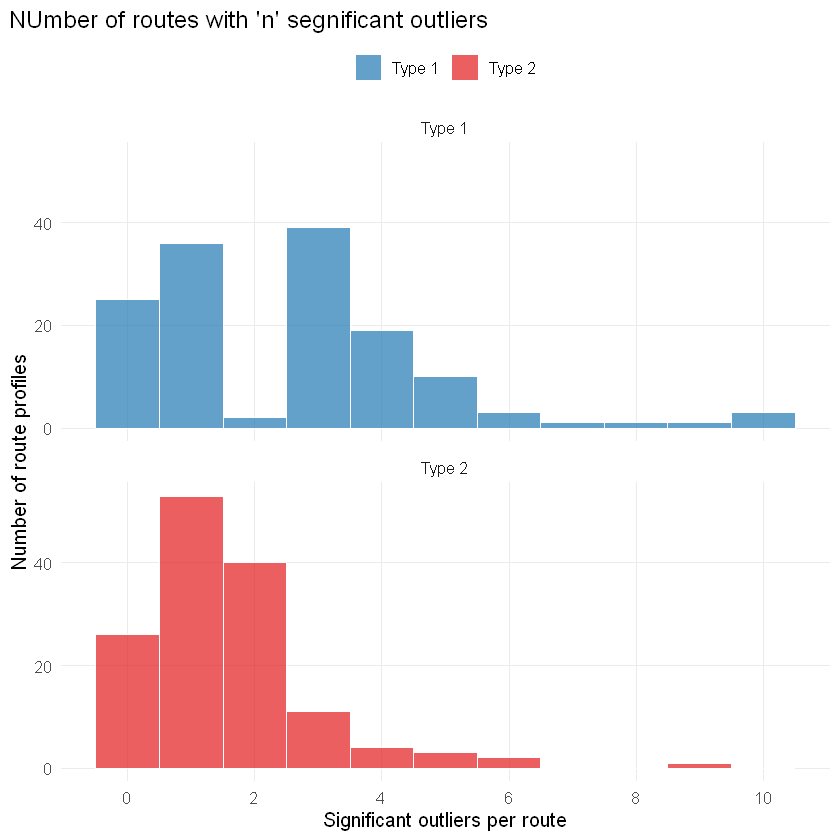

In [284]:
plot_outliers_per_route <- ggplot(
  analysis_data,
  aes(x = removed_outliers, fill = type)
) +
  geom_histogram(
    binwidth = 1,
    position = "identity",
    alpha = 0.7,
    color = "white",
    boundary = -0.5
  ) +
  facet_wrap(~ type, ncol = 1) +
  scale_x_continuous(breaks = pretty_breaks()) +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "NUmber of routes with 'n' segnificant outliers",
    x = "Significant outliers per route",
    y = "Number of route profiles",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_outliers_per_route

### Table 1: Route Profiles by Number of Significant Outliers

In [285]:
outlier_count_distribution_table %>%
  mutate(share_of_routes = percent(share_of_routes, accuracy = 0.1)) %>%
  arrange(type, problem_type, removed_outliers)

type,problem_type,removed_outliers,route_profiles,share_of_routes
<fct>,<fct>,<dbl>,<int>,<chr>
Type 1,HPP,0,0,0.0%
Type 1,HPP,1,3,8.6%
Type 1,HPP,2,0,0.0%
Type 1,HPP,3,15,42.9%
Type 1,HPP,4,10,28.6%
Type 1,HPP,5,5,14.3%
Type 1,HPP,6,1,2.9%
Type 1,HPP,7,1,2.9%
Type 1,HPP,8,0,0.0%


### Plot 2: Share of Routes With and Without Outliers

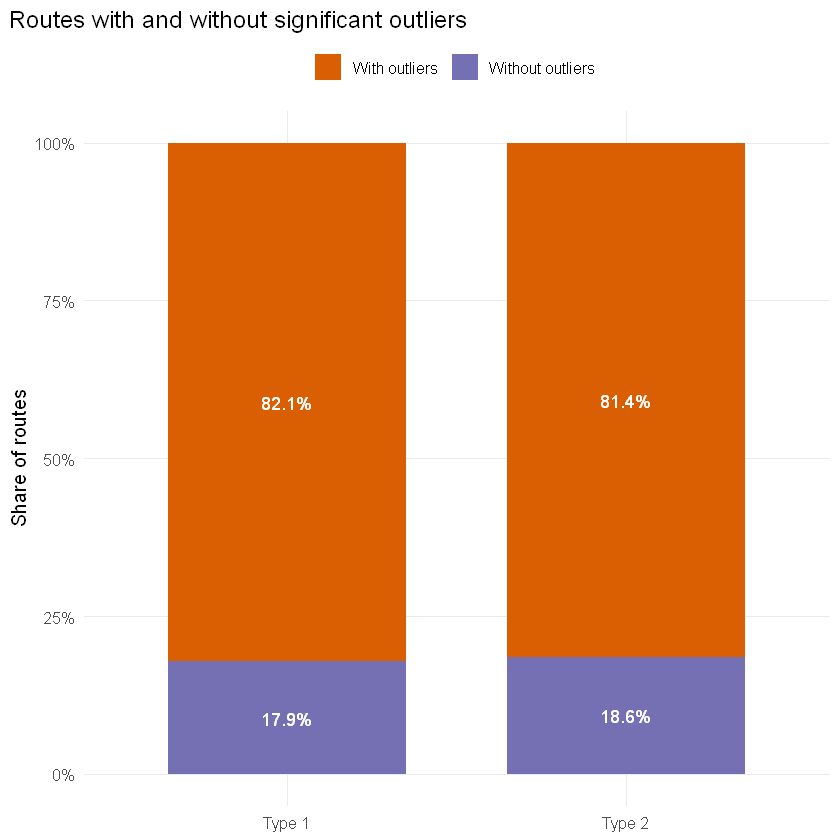

In [286]:
share_with_without_outliers <- analysis_data %>%
  mutate(outlier_status = if_else(has_outliers, "With outliers", "Without outliers")) %>%
  count(type, outlier_status, name = "route_profiles") %>%
  group_by(type) %>%
  mutate(share = route_profiles / sum(route_profiles)) %>%
  ungroup()

plot_share_with_without_outliers <- ggplot(
  share_with_without_outliers,
  aes(x = type, y = share, fill = outlier_status)
) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = percent(share, accuracy = 0.1)),
    position = position_stack(vjust = 0.5),
    color = "white",
    size = 3.8
  ) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("With outliers" = "#d95f02", "Without outliers" = "#7570b3")) +
  labs(
    title = "Routes with and without significant outliers",
    x = NULL,
    y = "Share of routes",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_share_with_without_outliers

### Plot 3: Share of Addresses Removed per Route

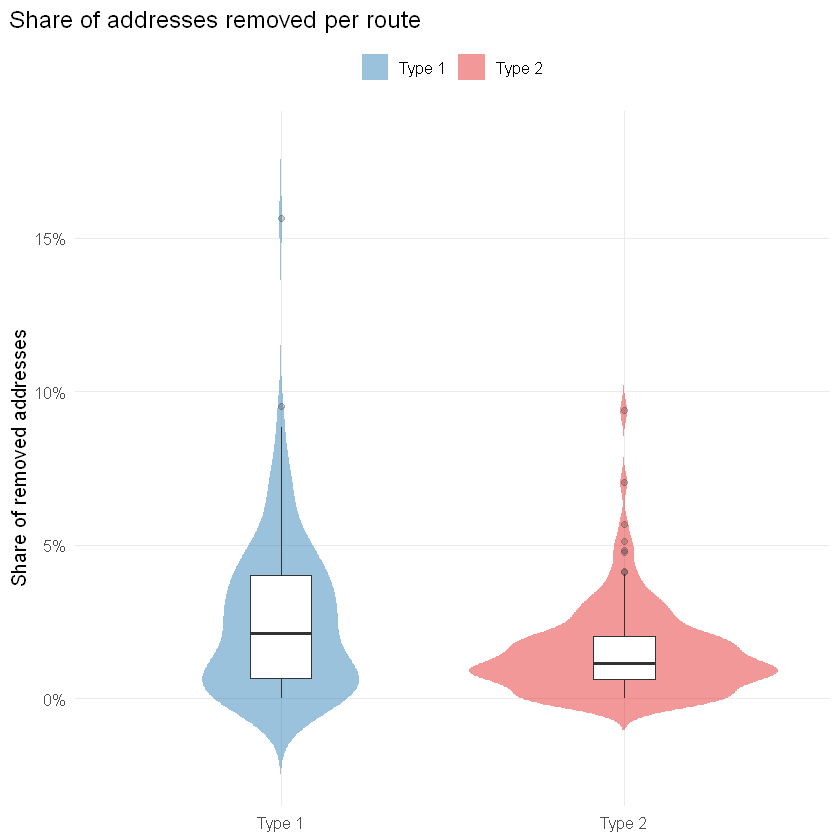

In [287]:
plot_removed_share <- ggplot(
  analysis_data,
  aes(x = type, y = removed_share, fill = type)
) +
  geom_violin(alpha = 0.45, trim = FALSE, color = NA) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.25, fill = "white") +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Share of addresses removed per route",
    x = NULL,
    y = "Share of removed addresses",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_removed_share

### Table 2: Outlier Addresses as a Share of All Addresses

In [288]:
outlier_address_summary_table %>%
  mutate(
    share_of_all_addresses = percent(share_of_all_addresses, accuracy = 0.1),
    mean_removed_share = percent(mean_removed_share, accuracy = 0.1)
  ) %>%
  arrange(type, problem_type)

type,problem_type,route_profiles,outlier_addresses,total_addresses,share_of_all_addresses,mean_removed_share
<fct>,<fct>,<int>,<dbl>,<dbl>,<chr>,<chr>
Type 1,HPP,35,126,3644,3.5%,3.6%
Type 1,TSP,105,229,12315,1.9%,2.2%
Type 2,HPP,35,68,3644,1.9%,1.9%
Type 2,TSP,105,150,12315,1.2%,1.4%


### Plot 4: Change in Route Length After Outlier Removal

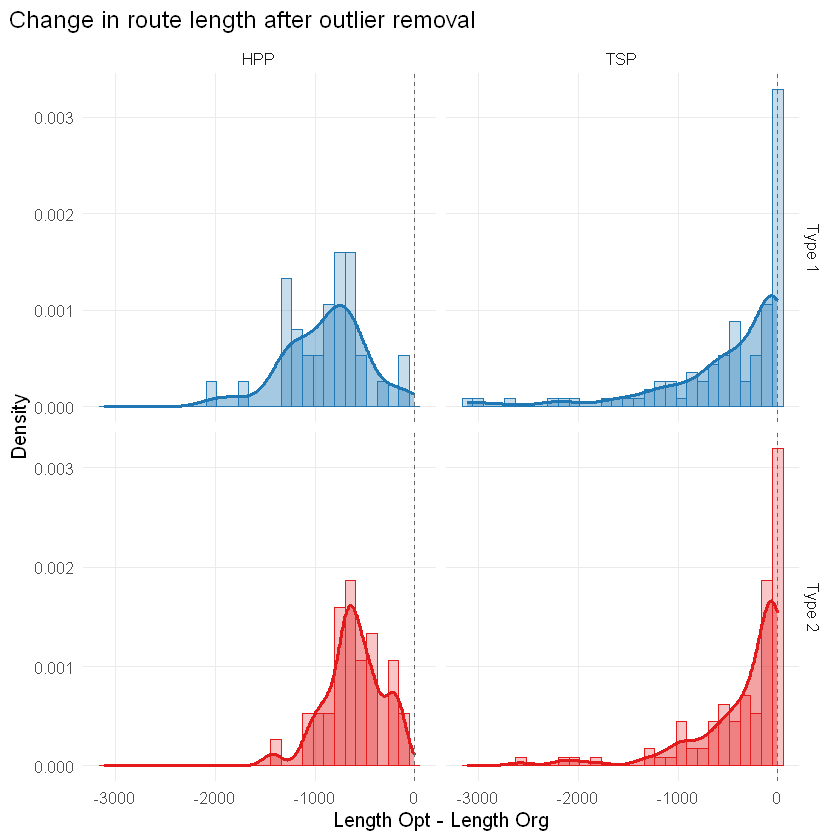

In [289]:
plot_length_change_distribution <- ggplot(
  analysis_data,
  aes(x = length_change, fill = type, color = type)
) +
  geom_histogram(aes(y = after_stat(density)), alpha = 0.25, position = "identity", bins = 30) +
  geom_density(linewidth = 0.9, alpha = 0.4, na.rm = TRUE) +
  facet_grid(rows = vars(type), cols = vars(problem_type), scales = "free_y", drop = FALSE) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey40") +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  scale_color_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Change in route length after outlier removal",
    x = "Length Opt - Length Org",
    y = "Density",
    fill = NULL,
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_length_change_distribution

## 6.4 Economic Impact of Outlier Removal

**Question:** How large is the economic effect of the identified outliers?

In [290]:
before_after_overall_table <- bind_rows(
  tibble(metric = "Revenue", before = sum(analysis_data$revenue_org), after = sum(analysis_data$revenue_opt)),
  tibble(metric = "Cost", before = sum(analysis_data$cost_org), after = sum(analysis_data$cost_opt)),
  tibble(metric = "Contribution Margin / DB", before = sum(analysis_data$db_org), after = sum(analysis_data$db_opt)),
  tibble(metric = "Route length/time", before = sum(analysis_data$length_org), after = sum(analysis_data$length_opt))
) %>%
  mutate(
    metric = factor(metric, levels = metric_order),
    delta = after - before,
    delta_pct = if_else(abs(before) > 1e-9, delta / before, NA_real_)
  ) %>%
  arrange(metric)

before_after_by_group_table <- bind_rows(
  analysis_data %>% group_by(type, problem_type) %>% summarise(metric = "Revenue", before = sum(revenue_org), after = sum(revenue_opt), .groups = "drop"),
  analysis_data %>% group_by(type, problem_type) %>% summarise(metric = "Cost", before = sum(cost_org), after = sum(cost_opt), .groups = "drop"),
  analysis_data %>% group_by(type, problem_type) %>% summarise(metric = "Contribution Margin / DB", before = sum(db_org), after = sum(db_opt), .groups = "drop"),
  analysis_data %>% group_by(type, problem_type) %>% summarise(metric = "Route length/time", before = sum(length_org), after = sum(length_opt), .groups = "drop")
) %>%
  mutate(
    metric = factor(metric, levels = metric_order),
    delta = after - before,
    delta_pct = if_else(abs(before) > 1e-9, delta / before, NA_real_)
  ) %>%
  arrange(type, problem_type, metric)

metrics_by_removed_units_table <- bind_rows(
  analysis_data %>% group_by(type, problem_type, removed_outliers) %>% summarise(metric = "Revenue", route_profiles = n(), before = sum(revenue_org), after = sum(revenue_opt), .groups = "drop"),
  analysis_data %>% group_by(type, problem_type, removed_outliers) %>% summarise(metric = "Cost", route_profiles = n(), before = sum(cost_org), after = sum(cost_opt), .groups = "drop"),
  analysis_data %>% group_by(type, problem_type, removed_outliers) %>% summarise(metric = "Contribution Margin / DB", route_profiles = n(), before = sum(db_org), after = sum(db_opt), .groups = "drop"),
  analysis_data %>% group_by(type, problem_type, removed_outliers) %>% summarise(metric = "Route length/time", route_profiles = n(), before = sum(length_org), after = sum(length_opt), .groups = "drop")
) %>%
  mutate(
    metric = factor(metric, levels = metric_order),
    delta = after - before,
    delta_pct = if_else(abs(before) > 1e-9, delta / before, NA_real_)
  ) %>%
  arrange(type, problem_type, removed_outliers, metric)

per_route_delta_summary_table <- bind_rows(
  summarise_route_metric(analysis_data, delta_revenue, "Delta Revenue"),
  summarise_route_metric(analysis_data, delta_cost, "Delta Cost"),
  summarise_route_metric(analysis_data, delta_db, "Delta DB"),
  summarise_route_metric(analysis_data, relative_db_improvement, "Relative DB Improvement")
) %>%
  arrange(type, problem_type, metric)

### Table 3: Before/After Summary for All Route Profiles

In [291]:
before_after_overall_table %>%
  mutate(delta_pct = percent(delta_pct, accuracy = 0.1))

metric,before,after,delta,delta_pct
<fct>,<dbl>,<dbl>,<dbl>,<chr>
Revenue,186058.18,184044.49,-2013.690,-1.1%
Cost,39760.53,35131.58,-4628.950,-11.6%
Contribution Margin / DB,146294.96,148909.89,2614.928,1.8%
Route length/time,1254511.60,1111996.20,-142515.400,-11.4%


### Table 4: Before/After Summary Split by Type and Problem Type

In [292]:
before_after_by_group_table %>%
  mutate(delta_pct = percent(delta_pct, accuracy = 0.1))

type,problem_type,metric,before,after,delta,delta_pct
<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
Type 1,HPP,Revenue,24551.76,23943.55,-608.2100,-2.5%
Type 1,HPP,Cost,7670.17,6439.32,-1230.8500,-16.0%
Type 1,HPP,Contribution Margin / DB,16880.91,17503.54,622.6385,3.7%
Type 1,HPP,Route length/time,194478.30,163270.30,-31208.0000,-16.0%
Type 1,TSP,Revenue,68477.33,67839.28,-638.0500,-0.9%
Type 1,TSP,Cost,13584.72,12087.07,-1497.6500,-11.0%
Type 1,TSP,Contribution Margin / DB,54891.69,55751.35,859.6678,1.6%
Type 1,TSP,Route length/time,478351.30,425617.40,-52733.9000,-11.0%
Type 2,HPP,Revenue,24551.76,24203.82,-347.9400,-1.4%


### Plot 5: Removed Outliers vs. Delta Revenue, Delta Cost, and Delta DB

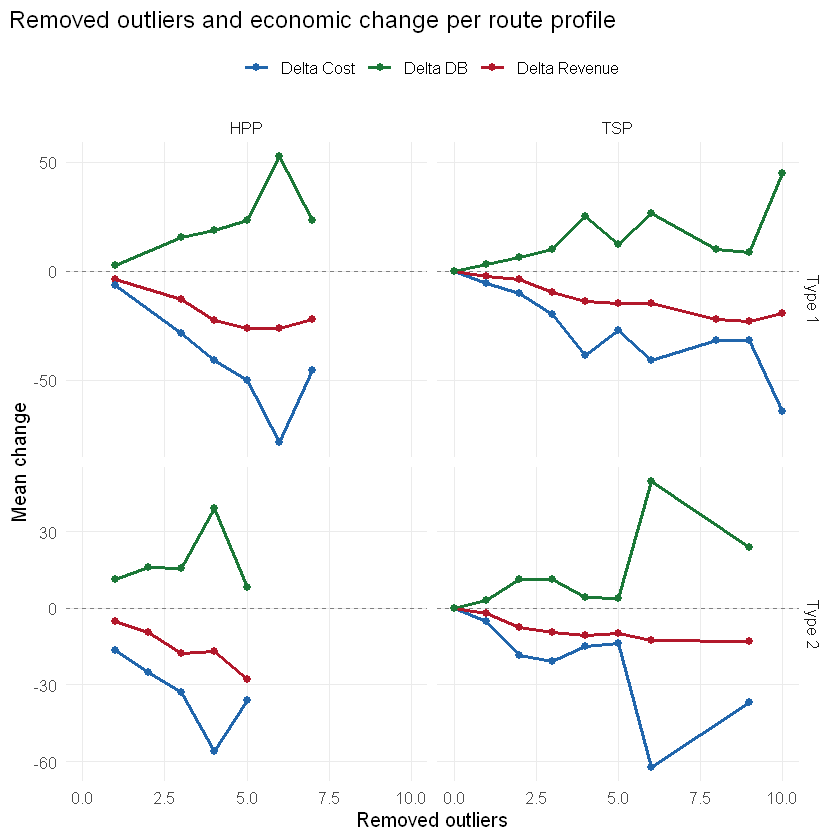

In [293]:
delta_by_removed_units_plot_data <- bind_rows(
  analysis_data %>% group_by(type, problem_type, removed_outliers) %>% summarise(value = mean(delta_revenue, na.rm = TRUE), .groups = "drop") %>% mutate(metric = "Delta Revenue"),
  analysis_data %>% group_by(type, problem_type, removed_outliers) %>% summarise(value = mean(delta_cost, na.rm = TRUE), .groups = "drop") %>% mutate(metric = "Delta Cost"),
  analysis_data %>% group_by(type, problem_type, removed_outliers) %>% summarise(value = mean(delta_db, na.rm = TRUE), .groups = "drop") %>% mutate(metric = "Delta DB")
)

plot_delta_by_removed_units <- ggplot(
  delta_by_removed_units_plot_data,
  aes(x = removed_outliers, y = value, color = metric)
) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  facet_grid(rows = vars(type), cols = vars(problem_type), scales = "free_y", drop = FALSE) +
  scale_color_manual(values = c("Delta Revenue" = "#b2182b", "Delta Cost" = "#2166ac", "Delta DB" = "#1b7837")) +
  labs(
    title = "Removed outliers and economic change per route profile",
    x = "Removed outliers",
    y = "Mean change",
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_delta_by_removed_units

### Table 5: Before/After Metrics as a Function of Removed Outliers

In [294]:
metrics_by_removed_units_table %>%
  mutate(delta_pct = percent(delta_pct, accuracy = 0.1))

type,problem_type,removed_outliers,metric,route_profiles,before,after,delta,delta_pct
<fct>,<fct>,<dbl>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Type 1,HPP,1,Revenue,3,2241.5600,2230.6800,-10.88000,-0.5%
Type 1,HPP,1,Cost,3,587.9600,568.6500,-19.31000,-3.3%
Type 1,HPP,1,Contribution Margin / DB,3,1653.4571,1661.8780,8.42088,0.5%
Type 1,HPP,1,Route length/time,3,14907.4000,14417.9000,-489.50000,-3.3%
Type 1,HPP,3,Revenue,15,10849.0400,10655.8000,-193.24000,-1.8%
Type 1,HPP,3,Cost,15,3474.8200,3047.4500,-427.37000,-12.3%
Type 1,HPP,3,Contribution Margin / DB,15,7373.8775,7608.0151,234.13762,3.2%
Type 1,HPP,3,Route length/time,15,88104.4000,77268.0000,-10836.40000,-12.3%
Type 1,HPP,4,Revenue,10,6525.4700,6301.9800,-223.49000,-3.4%


### Plot 6: Distribution of Relative DB Improvement per Route

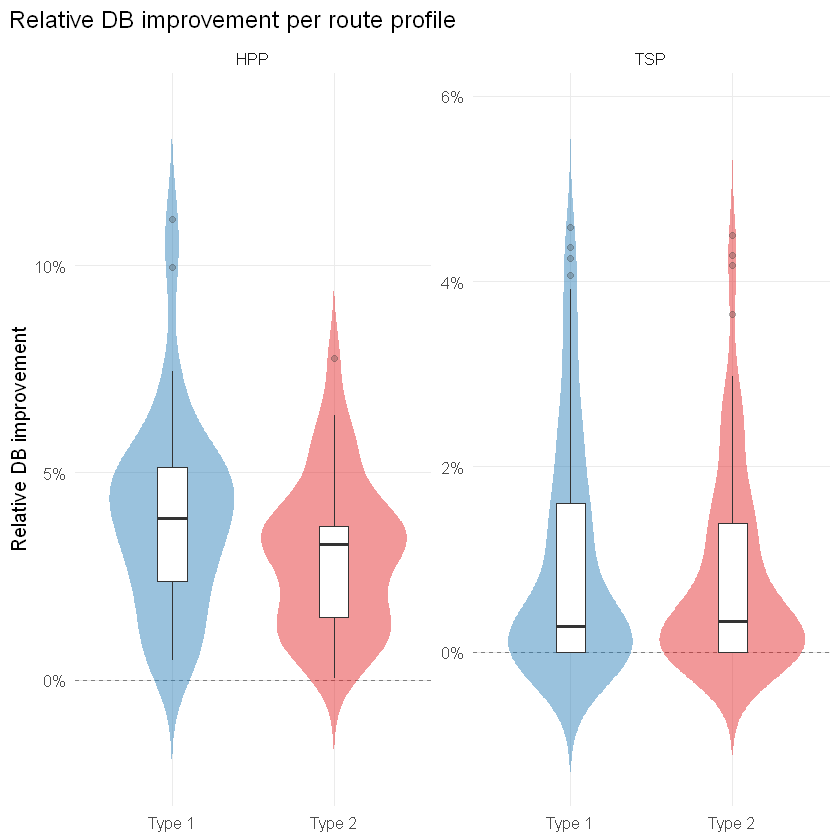

In [295]:
tsp_upper_whisker <- analysis_data %>%
  filter(problem_type == "TSP") %>%
  summarise(
    q25 = quantile(relative_db_improvement, 0.25, na.rm = TRUE),
    q75 = quantile(relative_db_improvement, 0.75, na.rm = TRUE),
    iqr = IQR(relative_db_improvement, na.rm = TRUE)
  ) %>%
  mutate(upper_whisker = q75 + 1.5 * iqr) %>%
  pull(upper_whisker)

relative_db_plot_data <- analysis_data %>%
  filter(problem_type != "TSP" | relative_db_improvement <= tsp_upper_whisker)

plot_relative_db_improvement <- ggplot(
  relative_db_plot_data,
  aes(x = type, y = relative_db_improvement, fill = type)
) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_violin(alpha = 0.45, trim = FALSE, color = NA) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.25, fill = "white") +
  facet_wrap(~ problem_type, ncol = 2, scales = "free_y", drop = FALSE) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Relative DB improvement per route profile",
    x = NULL,
    y = "Relative DB improvement",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_relative_db_improvement

### Table 6: Per-Route Summary Statistics for Economic Change

In [296]:
per_route_delta_summary_table %>%
  mutate(
    mean = if_else(metric == "Relative DB Improvement", percent(mean, accuracy = 0.1), format(round(mean, 2), nsmall = 2)),
    median = if_else(metric == "Relative DB Improvement", percent(median, accuracy = 0.1), format(round(median, 2), nsmall = 2)),
    q25 = if_else(metric == "Relative DB Improvement", percent(q25, accuracy = 0.1), format(round(q25, 2), nsmall = 2)),
    q75 = if_else(metric == "Relative DB Improvement", percent(q75, accuracy = 0.1), format(round(q75, 2), nsmall = 2))
  )

type,problem_type,metric,mean,median,q25,q75
<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
Type 1,HPP,Delta Cost,-35.17,-31.87,-46.06,-25.06
Type 1,HPP,Delta DB,17.79,18.25,12.32,21.45
Type 1,HPP,Delta Revenue,-17.38,-16.20,-25.84,-11.09
Type 1,HPP,Relative DB Improvement,4.0%,3.9%,2.4%,5.1%
Type 1,TSP,Delta Cost,-14.26,-7.00,-19.32,-0.72
Type 1,TSP,Delta DB,8.19,2.52,0.17,10.71
Type 1,TSP,Delta Revenue,-6.08,-2.60,-10.04,-0.30
Type 1,TSP,Relative DB Improvement,2.9%,0.7%,0.0%,2.3%
Type 2,HPP,Delta Cost,-24.14,-24.15,-28.22,-16.79


### Plot 7: Revenue Lost vs. Cost Saved

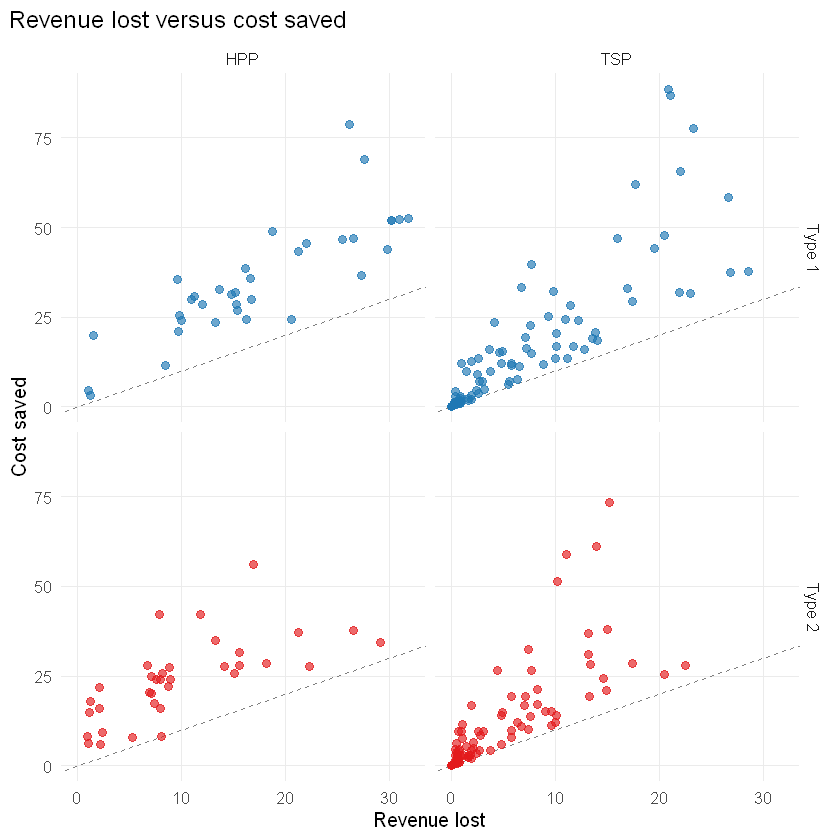

In [297]:
plot_break_even_scatter <- ggplot(
  analysis_data,
  aes(x = revenue_lost, y = cost_saved, color = type)
) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "grey50") +
  geom_point(alpha = 0.65, size = 2.2) +
  facet_grid(rows = vars(type), cols = vars(problem_type), drop = FALSE) +
  scale_color_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Revenue lost versus cost saved",
    x = "Revenue lost",
    y = "Cost saved",
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_break_even_scatter

### Plot 8: Cumulative DB Improvement as a Function of Removed Addresses

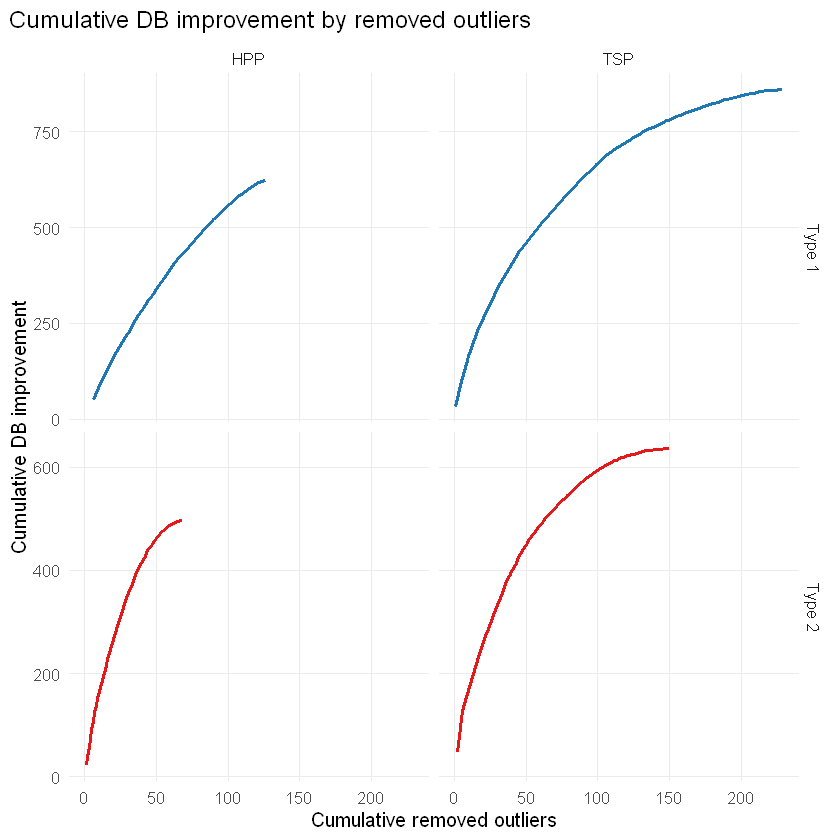

In [298]:
cumulative_db_plot_data <- analysis_data %>%
  filter(removed_outliers > 0) %>%
  group_by(type, problem_type) %>%
  arrange(desc(delta_db / removed_outliers), .by_group = TRUE) %>%
  mutate(
    cumulative_removed_outliers = cumsum(removed_outliers),
    cumulative_db_improvement = cumsum(delta_db)
  ) %>%
  ungroup()

plot_cumulative_db_improvement <- ggplot(
  cumulative_db_plot_data,
  aes(x = cumulative_removed_outliers, y = cumulative_db_improvement, color = type)
) +
  geom_line(linewidth = 1) +
  facet_grid(rows = vars(type), cols = vars(problem_type), scales = "free_y", drop = FALSE) +
  scale_color_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Cumulative DB improvement by removed outliers",
    x = "Cumulative removed outliers",
    y = "Cumulative DB improvement",
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_cumulative_db_improvement

## 6.5 Existing Route Efficiency

**Question:** How efficient are the existing route sequences compared with the Type 2 optimization?

This section separates route-sequence efficiency from the economic diagnosis. The focus is on how much shorter the Type 2 optimization can make the route and how that relates to agreement or disagreement between the Type 1 and Type 2 outlier sets.

In [299]:
parse_outlier_set <- function(text_value) {
  if (is.na(text_value) || !nzchar(text_value)) {
    return(integer(0))
  }

  cleaned <- gsub("\\[|\\]", "", text_value)
  cleaned <- trimws(cleaned)

  if (!nzchar(cleaned)) {
    return(integer(0))
  }

  as.integer(trimws(strsplit(cleaned, ",")[[1]]))
}

set_relation <- function(set1, set2) {
  if (length(set1) == 0 && length(set2) == 0) {
    return("Both empty")
  }

  if (setequal(set1, set2)) {
    return("Equal")
  }

  if (all(set1 %in% set2)) {
    return("T1 included in T2")
  }

  if (all(set2 %in% set1)) {
    return("T2 included in T1")
  }

  "Different"
}

jaccard_index <- function(set1, set2) {
  union_size <- length(union(set1, set2))

  if (union_size == 0) {
    return(1)
  }

  length(intersect(set1, set2)) / union_size
}

length_tolerance <- 1e-6
relation_levels <- c("Both empty", "Equal", "T1 included in T2", "T2 included in T1", "Different")

paired_route_data <- analysis_data %>%
  group_by(route_id, apr_profile, week_profile, problem_type, transportform, route_segment, original_addresses) %>%
  summarise(
    length_org_t1 = length_org[type == "Type 1"][1],
    length_opt_t1 = length_opt[type == "Type 1"][1],
    length_org_t2 = length_org[type == "Type 2"][1],
    length_opt_t2 = length_opt[type == "Type 2"][1],
    revenue_org_t1 = revenue_org[type == "Type 1"][1],
    revenue_opt_t1 = revenue_opt[type == "Type 1"][1],
    revenue_org_t2 = revenue_org[type == "Type 2"][1],
    revenue_opt_t2 = revenue_opt[type == "Type 2"][1],
    cost_org_t1 = cost_org[type == "Type 1"][1],
    cost_opt_t1 = cost_opt[type == "Type 1"][1],
    cost_org_t2 = cost_org[type == "Type 2"][1],
    cost_opt_t2 = cost_opt[type == "Type 2"][1],
    db_org_t1 = db_org[type == "Type 1"][1],
    db_opt_t1 = db_opt[type == "Type 1"][1],
    db_org_t2 = db_org[type == "Type 2"][1],
    db_opt_t2 = db_opt[type == "Type 2"][1],
    removed_outliers_t1 = removed_outliers[type == "Type 1"][1],
    removed_outliers_t2 = removed_outliers[type == "Type 2"][1],
    set_string_t1 = outlier_set_string[type == "Type 1"][1],
    set_string_t2 = outlier_set_string[type == "Type 2"][1],
    .groups = "drop"
  ) %>%
  mutate(
    set_t1 = lapply(set_string_t1, parse_outlier_set),
    set_t2 = lapply(set_string_t2, parse_outlier_set),
    outlier_set_relation = factor(mapply(set_relation, set_t1, set_t2), levels = relation_levels),
    jaccard = mapply(jaccard_index, set_t1, set_t2),
    type2_abs_length_saving = length_org_t2 - length_opt_t2,
    type2_rel_length_saving = if_else(length_org_t2 > 0, type2_abs_length_saving / length_org_t2, NA_real_),
    route_efficiency_status = case_when(
      abs(type2_abs_length_saving) <= length_tolerance ~ "Equal within tolerance",
      type2_abs_length_saving > length_tolerance ~ "Original longer than optimal",
      TRUE ~ "Original shorter than optimal"
    ),
    delta_db_t1 = db_opt_t1 - db_org_t1,
    delta_db_t2 = db_opt_t2 - db_org_t2,
    revenue_lost_t1 = revenue_org_t1 - revenue_opt_t1,
    revenue_lost_t2 = revenue_org_t2 - revenue_opt_t2,
    cost_saved_t1 = cost_org_t1 - cost_opt_t1,
    cost_saved_t2 = cost_org_t2 - cost_opt_t2,
    delta_db_difference = delta_db_t2 - delta_db_t1,
    revenue_lost_difference = revenue_lost_t2 - revenue_lost_t1,
    cost_saved_difference = cost_saved_t2 - cost_saved_t1,
    db_improvement_comparison = case_when(
      delta_db_t1 > delta_db_t2 + length_tolerance ~ "Type 1 larger",
      delta_db_t2 > delta_db_t1 + length_tolerance ~ "Type 2 larger",
      TRUE ~ "Same"
    )
  )

route_efficiency_status_table <- bind_rows(
  paired_route_data %>%
    count(route_efficiency_status, name = "route_profiles") %>%
    mutate(problem_type = "All", transportform = "All"),
  paired_route_data %>%
    count(problem_type, transportform, route_efficiency_status, name = "route_profiles")
) %>%
  group_by(problem_type, transportform) %>%
  mutate(share_of_routes = route_profiles / sum(route_profiles)) %>%
  ungroup()

type2_length_summary_table <- bind_rows(
  paired_route_data %>%
    summarise(
      problem_type = "All",
      transportform = "All",
      route_profiles = n(),
      original_length_total = sum(length_org_t2, na.rm = TRUE),
      optimized_length_total = sum(length_opt_t2, na.rm = TRUE),
      absolute_saving_total = sum(type2_abs_length_saving, na.rm = TRUE),
      relative_saving_total = absolute_saving_total / original_length_total,
      original_length_mean = mean(length_org_t2, na.rm = TRUE),
      optimized_length_mean = mean(length_opt_t2, na.rm = TRUE),
      absolute_saving_mean = mean(type2_abs_length_saving, na.rm = TRUE),
      relative_saving_mean = mean(type2_rel_length_saving, na.rm = TRUE)
    ),
  paired_route_data %>%
    group_by(problem_type, transportform) %>%
    summarise(
      route_profiles = n(),
      original_length_total = sum(length_org_t2, na.rm = TRUE),
      optimized_length_total = sum(length_opt_t2, na.rm = TRUE),
      absolute_saving_total = sum(type2_abs_length_saving, na.rm = TRUE),
      relative_saving_total = absolute_saving_total / original_length_total,
      original_length_mean = mean(length_org_t2, na.rm = TRUE),
      optimized_length_mean = mean(length_opt_t2, na.rm = TRUE),
      absolute_saving_mean = mean(type2_abs_length_saving, na.rm = TRUE),
      relative_saving_mean = mean(type2_rel_length_saving, na.rm = TRUE),
      .groups = "drop"
    )
)

outlier_relation_table <- bind_rows(
  paired_route_data %>%
    count(outlier_set_relation, name = "route_profiles") %>%
    mutate(problem_type = "All", transportform = "All"),
  paired_route_data %>%
    count(problem_type, transportform, outlier_set_relation, name = "route_profiles")
) %>%
  left_join(
    bind_rows(
      paired_route_data %>%
        group_by(outlier_set_relation) %>%
        summarise(mean_jaccard = mean(jaccard, na.rm = TRUE), median_jaccard = median(jaccard, na.rm = TRUE), .groups = "drop") %>%
        mutate(problem_type = "All", transportform = "All"),
      paired_route_data %>%
        group_by(problem_type, transportform, outlier_set_relation) %>%
        summarise(mean_jaccard = mean(jaccard, na.rm = TRUE), median_jaccard = median(jaccard, na.rm = TRUE), .groups = "drop")
    ),
    by = c("problem_type", "transportform", "outlier_set_relation")
  ) %>%
  group_by(problem_type, transportform) %>%
  mutate(share_of_routes = route_profiles / sum(route_profiles)) %>%
  ungroup()

### Table 7: Route Efficiency Status

In [300]:
route_efficiency_status_table %>%
  mutate(share_of_routes = percent(share_of_routes, accuracy = 0.1)) %>%
  arrange(problem_type, transportform, route_efficiency_status)

route_efficiency_status,route_profiles,problem_type,transportform,share_of_routes
<chr>,<int>,<chr>,<chr>,<chr>
Equal within tolerance,26,All,All,18.6%
Original longer than optimal,114,All,All,81.4%
Original longer than optimal,35,HPP,car,100.0%
Equal within tolerance,26,TSP,foot,24.8%
Original longer than optimal,79,TSP,foot,75.2%


### Table 8: Type 2 Length Summary

In [301]:
type2_length_summary_table %>%
  mutate(
    relative_saving_total = percent(relative_saving_total, accuracy = 0.1),
    relative_saving_mean = percent(relative_saving_mean, accuracy = 0.1)
  ) %>%
  arrange(problem_type, transportform)

problem_type,transportform,route_profiles,original_length_total,optimized_length_total,absolute_saving_total,relative_saving_total,original_length_mean,optimized_length_mean,absolute_saving_mean,relative_saving_mean
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
All,All,140,581682.0,523108.5,58573.5,10.1%,4154.871,3736.489,418.3821,9.1%
HPP,car,35,179877.8,158459.8,21418.0,11.9%,5139.366,4527.423,611.9429,12.0%
TSP,foot,105,401804.2,364648.7,37155.5,9.2%,3826.707,3472.845,353.8619,8.2%


### Table 9: Relation Between Type 1 and Type 2 Outlier Sets

In [302]:
outlier_relation_table %>%
  mutate(
    share_of_routes = percent(share_of_routes, accuracy = 0.1),
    mean_jaccard = round(mean_jaccard, 3),
    median_jaccard = round(median_jaccard, 3)
  ) %>%
  arrange(problem_type, transportform, outlier_set_relation)

outlier_set_relation,route_profiles,problem_type,transportform,mean_jaccard,median_jaccard,share_of_routes
<fct>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>
Both empty,17,All,All,1.000,1.000,12.1%
Equal,18,All,All,1.000,1.000,12.9%
T1 included in T2,8,All,All,0.000,0.000,5.7%
T2 included in T1,57,All,All,0.410,0.500,40.7%
Different,40,All,All,0.114,0.000,28.6%
Equal,2,HPP,car,1.000,1.000,5.7%
T2 included in T1,15,HPP,car,0.453,0.500,42.9%
Different,18,HPP,car,0.121,0.083,51.4%
Both empty,17,TSP,foot,1.000,1.000,16.2%


### Plot 9: Relative Route-Length Saving Under Type 2

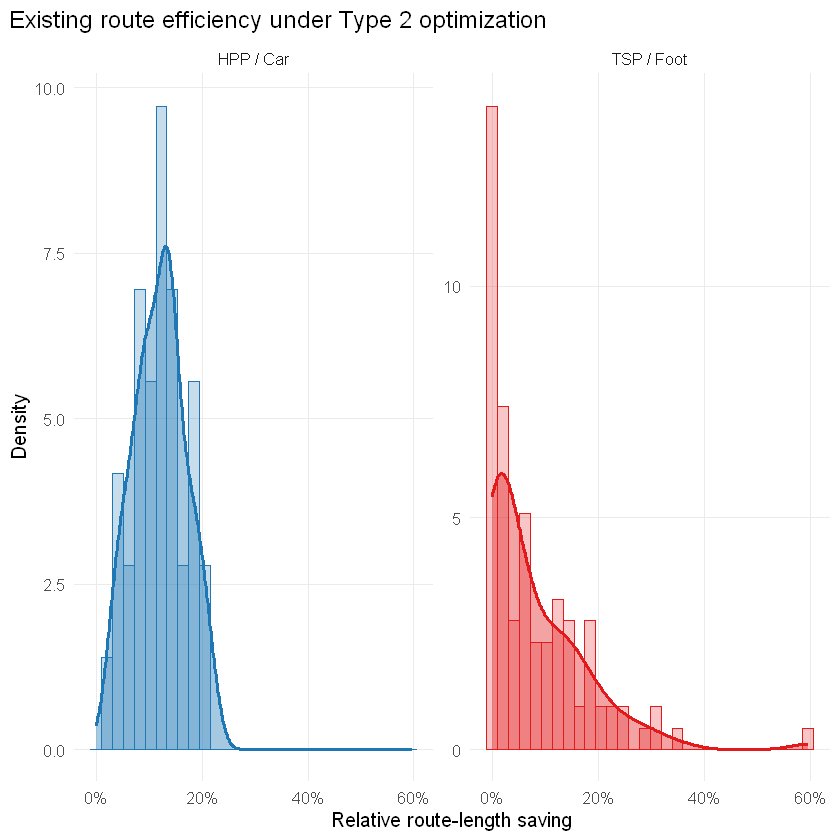

In [303]:
plot_type2_relative_length_saving <- ggplot(
  paired_route_data,
  aes(x = type2_rel_length_saving, fill = problem_type, color = problem_type)
) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, alpha = 0.25, position = "identity") +
  geom_density(linewidth = 0.9, alpha = 0.4, na.rm = TRUE) +
  facet_wrap(~ route_segment, ncol = 2, scales = "free_y", drop = FALSE) +
  scale_x_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  scale_color_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Existing route efficiency under Type 2 optimization",
    x = "Relative route-length saving",
    y = "Density",
    fill = NULL,
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_type2_relative_length_saving

### Plot 10: Type 1 Length Versus Type 2 Length

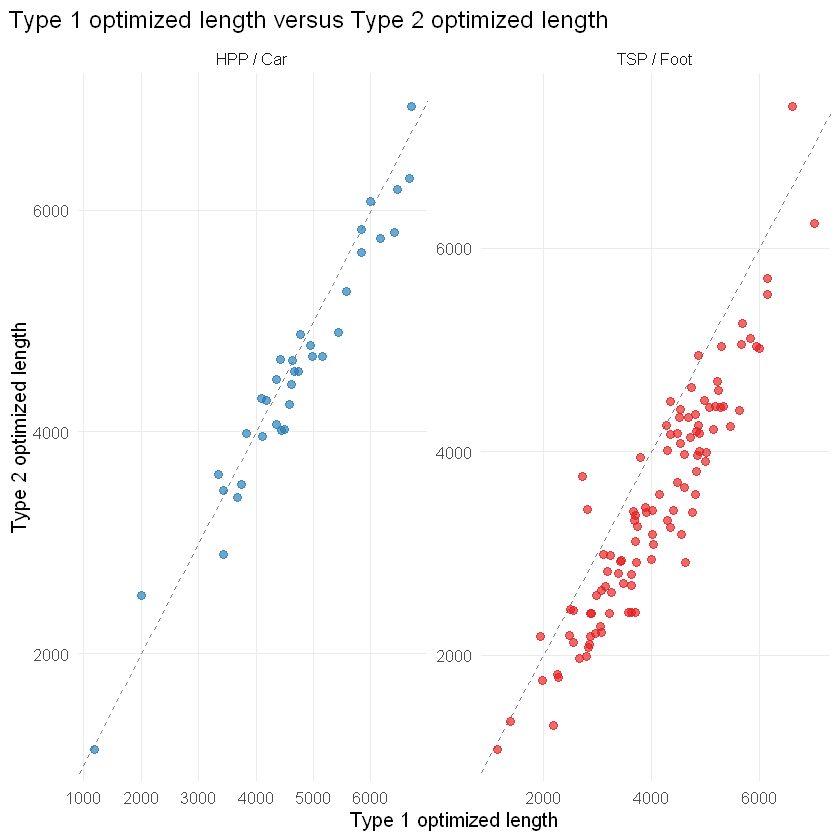

In [304]:
plot_t1_t2_length_scatter <- ggplot(
  paired_route_data,
  aes(x = length_opt_t1, y = length_opt_t2, color = problem_type)
) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "grey50") +
  geom_point(alpha = 0.65, size = 2.2) +
  facet_wrap(~ route_segment, ncol = 2, scales = "free", drop = FALSE) +
  scale_color_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Type 1 optimized length versus Type 2 optimized length",
    x = "Type 1 optimized length",
    y = "Type 2 optimized length",
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_t1_t2_length_scatter

### Plot 11: Outlier-Set Relations

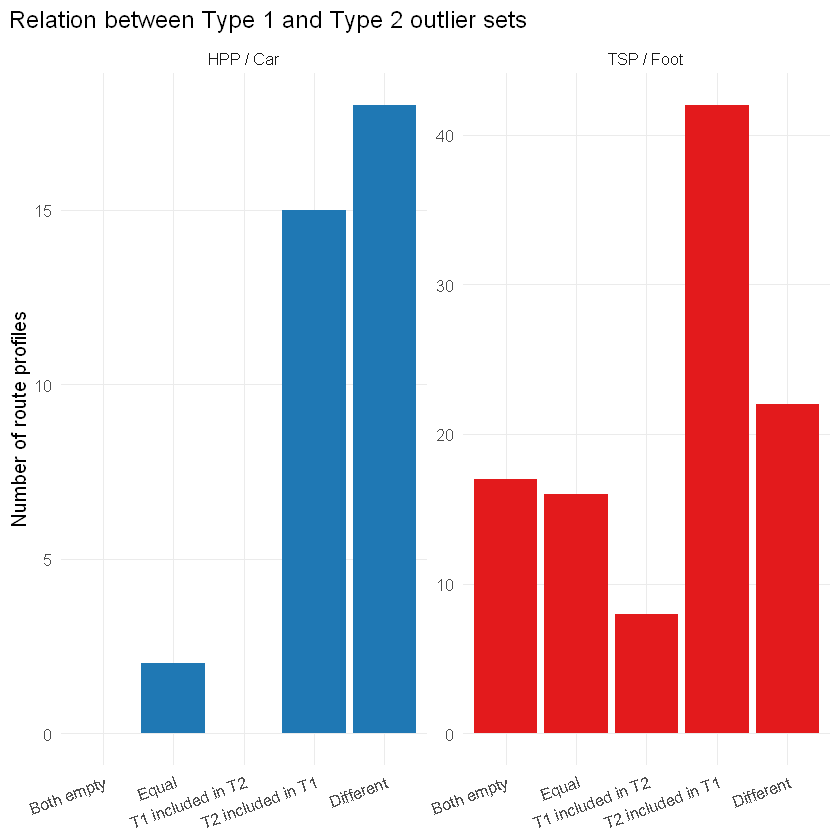

In [305]:
plot_outlier_set_relations <- ggplot(
  paired_route_data,
  aes(x = outlier_set_relation, fill = problem_type)
) +
  geom_bar() +
  facet_wrap(~ route_segment, ncol = 2, scales = "free_y", drop = FALSE) +
  scale_fill_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Relation between Type 1 and Type 2 outlier sets",
    x = NULL,
    y = "Number of route profiles",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 20, hjust = 1),
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_outlier_set_relations

### Plot 12: Route-Length Saving by Outlier-Set Relation

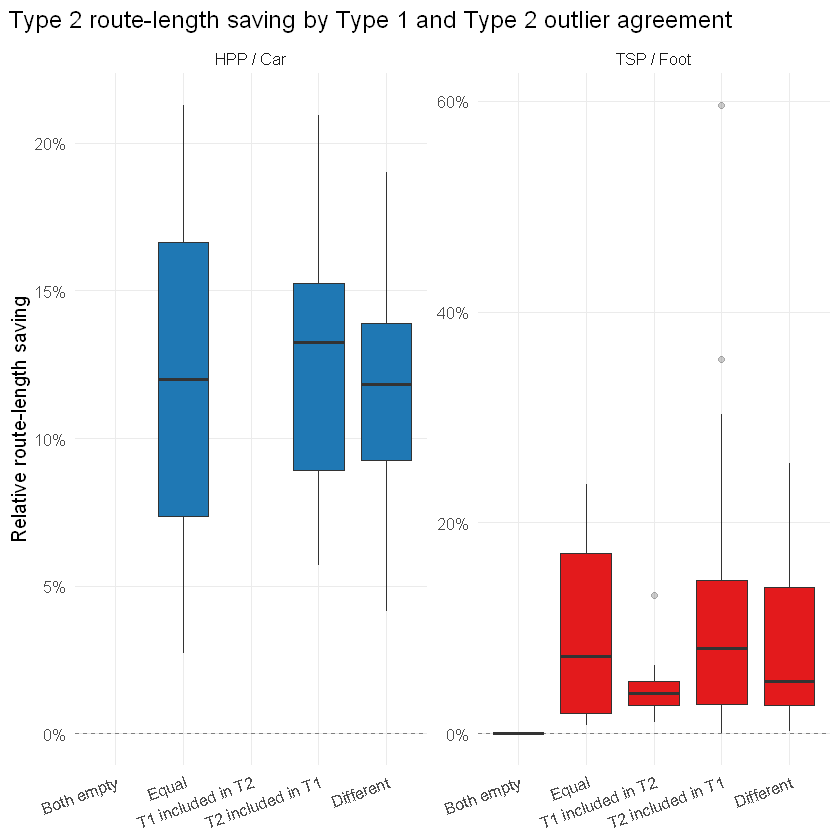

In [306]:
plot_length_saving_by_relation <- ggplot(
  paired_route_data,
  aes(x = outlier_set_relation, y = type2_rel_length_saving, fill = problem_type)
) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_boxplot(outlier.alpha = 0.25) +
  facet_wrap(~ route_segment, ncol = 2, scales = "free_y", drop = FALSE) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Type 2 route-length saving by Type 1 and Type 2 outlier agreement",
    x = NULL,
    y = "Relative route-length saving",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 20, hjust = 1),
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_length_saving_by_relation

## 6.6 Type 1 Versus Type 2 - Robustness of the Economic Diagnosis

**Question:** How much does the economic diagnosis change when sequence bias is removed?

This section shifts the focus from route length to economic outcomes and compares the Type 1 and Type 2 diagnoses directly at the route-profile level.

In [307]:
type1_type2_metric_table <- tibble(
  metric = c(
    "Revenue after removal",
    "Cost after removal",
    "DB after removal",
    "Revenue lost",
    "Cost saved",
    "DB improvement"
  ),
  type1 = c(
    mean(paired_route_data$revenue_opt_t1, na.rm = TRUE),
    mean(paired_route_data$cost_opt_t1, na.rm = TRUE),
    mean(paired_route_data$db_opt_t1, na.rm = TRUE),
    mean(paired_route_data$revenue_lost_t1, na.rm = TRUE),
    mean(paired_route_data$cost_saved_t1, na.rm = TRUE),
    mean(paired_route_data$delta_db_t1, na.rm = TRUE)
  ),
  type2 = c(
    mean(paired_route_data$revenue_opt_t2, na.rm = TRUE),
    mean(paired_route_data$cost_opt_t2, na.rm = TRUE),
    mean(paired_route_data$db_opt_t2, na.rm = TRUE),
    mean(paired_route_data$revenue_lost_t2, na.rm = TRUE),
    mean(paired_route_data$cost_saved_t2, na.rm = TRUE),
    mean(paired_route_data$delta_db_t2, na.rm = TRUE)
  )
) %>%
  mutate(
    difference = type2 - type1,
    relative_difference = if_else(abs(type1) > 1e-9, difference / abs(type1), NA_real_)
  )

type1_type2_difference_summary_table <- bind_rows(
  paired_route_data %>% group_by(problem_type, transportform) %>% summarise(metric = "DB improvement", mean = mean(delta_db_difference, na.rm = TRUE), median = median(delta_db_difference, na.rm = TRUE), q25 = quantile(delta_db_difference, 0.25, na.rm = TRUE), q75 = quantile(delta_db_difference, 0.75, na.rm = TRUE), mean_relative_difference = mean(if_else(abs(delta_db_t1) > 1e-9, delta_db_difference / abs(delta_db_t1), NA_real_), na.rm = TRUE), .groups = "drop"),
  paired_route_data %>% group_by(problem_type, transportform) %>% summarise(metric = "Revenue lost", mean = mean(revenue_lost_difference, na.rm = TRUE), median = median(revenue_lost_difference, na.rm = TRUE), q25 = quantile(revenue_lost_difference, 0.25, na.rm = TRUE), q75 = quantile(revenue_lost_difference, 0.75, na.rm = TRUE), mean_relative_difference = mean(if_else(abs(revenue_lost_t1) > 1e-9, revenue_lost_difference / abs(revenue_lost_t1), NA_real_), na.rm = TRUE), .groups = "drop"),
  paired_route_data %>% group_by(problem_type, transportform) %>% summarise(metric = "Cost saved", mean = mean(cost_saved_difference, na.rm = TRUE), median = median(cost_saved_difference, na.rm = TRUE), q25 = quantile(cost_saved_difference, 0.25, na.rm = TRUE), q75 = quantile(cost_saved_difference, 0.75, na.rm = TRUE), mean_relative_difference = mean(if_else(abs(cost_saved_t1) > 1e-9, cost_saved_difference / abs(cost_saved_t1), NA_real_), na.rm = TRUE), .groups = "drop"),
  paired_route_data %>% group_by(problem_type, transportform) %>% summarise(metric = "Revenue after removal", mean = mean(revenue_opt_t2 - revenue_opt_t1, na.rm = TRUE), median = median(revenue_opt_t2 - revenue_opt_t1, na.rm = TRUE), q25 = quantile(revenue_opt_t2 - revenue_opt_t1, 0.25, na.rm = TRUE), q75 = quantile(revenue_opt_t2 - revenue_opt_t1, 0.75, na.rm = TRUE), mean_relative_difference = mean(if_else(abs(revenue_opt_t1) > 1e-9, (revenue_opt_t2 - revenue_opt_t1) / abs(revenue_opt_t1), NA_real_), na.rm = TRUE), .groups = "drop"),
  paired_route_data %>% group_by(problem_type, transportform) %>% summarise(metric = "Cost after removal", mean = mean(cost_opt_t2 - cost_opt_t1, na.rm = TRUE), median = median(cost_opt_t2 - cost_opt_t1, na.rm = TRUE), q25 = quantile(cost_opt_t2 - cost_opt_t1, 0.25, na.rm = TRUE), q75 = quantile(cost_opt_t2 - cost_opt_t1, 0.75, na.rm = TRUE), mean_relative_difference = mean(if_else(abs(cost_opt_t1) > 1e-9, (cost_opt_t2 - cost_opt_t1) / abs(cost_opt_t1), NA_real_), na.rm = TRUE), .groups = "drop"),
  paired_route_data %>% group_by(problem_type, transportform) %>% summarise(metric = "DB after removal", mean = mean(db_opt_t2 - db_opt_t1, na.rm = TRUE), median = median(db_opt_t2 - db_opt_t1, na.rm = TRUE), q25 = quantile(db_opt_t2 - db_opt_t1, 0.25, na.rm = TRUE), q75 = quantile(db_opt_t2 - db_opt_t1, 0.75, na.rm = TRUE), mean_relative_difference = mean(if_else(abs(db_opt_t1) > 1e-9, (db_opt_t2 - db_opt_t1) / abs(db_opt_t1), NA_real_), na.rm = TRUE), .groups = "drop")
)

db_improvement_comparison_table <- paired_route_data %>%
  count(problem_type, transportform, db_improvement_comparison, name = "route_profiles") %>%
  group_by(problem_type, transportform) %>%
  mutate(share_of_routes = route_profiles / sum(route_profiles)) %>%
  ungroup()

outlier_overlap_table <- paired_route_data %>%
  count(problem_type, transportform, outlier_set_relation, name = "route_profiles") %>%
  left_join(
    paired_route_data %>%
      group_by(problem_type, transportform, outlier_set_relation) %>%
      summarise(
        mean_jaccard = mean(jaccard, na.rm = TRUE),
        median_jaccard = median(jaccard, na.rm = TRUE),
        .groups = "drop"
      ),
    by = c("problem_type", "transportform", "outlier_set_relation")
  ) %>%
  group_by(problem_type, transportform) %>%
  mutate(share_of_routes = route_profiles / sum(route_profiles)) %>%
  ungroup()

### Table 10: Type 1 Versus Type 2 Mean Comparison

In [308]:
type1_type2_metric_table %>%
  mutate(relative_difference = percent(relative_difference, accuracy = 0.1))

metric,type1,type2,difference,relative_difference
<chr>,<dbl>,<dbl>,<dbl>,<chr>
Revenue after removal,655.591643,659.011857,3.420214,0.5%
Cost after removal,132.331357,118.608500,-13.722857,-10.4%
DB after removal,523.249269,540.392821,17.143551,3.3%
Revenue lost,8.901857,5.481643,-3.420214,-38.4%
Cost saved,19.489286,13.574643,-5.914643,-30.3%
DB improvement,10.587902,8.090158,-2.497744,-23.6%


### Table 11: Per-Route Difference Summary

In [309]:
type1_type2_difference_summary_table %>%
  mutate(mean_relative_difference = percent(mean_relative_difference, accuracy = 0.1)) %>%
  arrange(problem_type, transportform, metric)

problem_type,transportform,metric,mean,median,q25,q75,mean_relative_difference
<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
HPP,car,Cost after removal,-5.428286,-7.230000,-12.580000,3.975000e+00,-2.4%
HPP,car,Cost saved,-11.025714,-10.160000,-18.360000,-1.925000e+00,-20.8%
HPP,car,DB after removal,12.857746,9.907528,7.760408,1.962114e+01,2.7%
HPP,car,DB improvement,-3.594931,-3.619408,-8.396226,1.367398e+00,-9.1%
HPP,car,Revenue after removal,7.436286,8.630000,0.840000,1.413000e+01,1.2%
HPP,car,Revenue lost,-7.436286,-8.630000,-14.130000,-8.400000e-01,-25.5%
TSP,foot,Cost after removal,-16.487714,-17.120000,-24.140000,-1.019000e+01,-14.4%
TSP,foot,Cost saved,-4.210952,-1.160000,-8.320000,0.000000e+00,1.9%
TSP,foot,DB after removal,18.572153,18.460000,12.615280,2.565878e+01,3.6%


### Table 12: Which Type Gives the Larger DB Improvement?

In [310]:
db_improvement_comparison_table %>%
  mutate(share_of_routes = percent(share_of_routes, accuracy = 0.1)) %>%
  arrange(problem_type, transportform, db_improvement_comparison)

problem_type,transportform,db_improvement_comparison,route_profiles,share_of_routes
<fct>,<fct>,<chr>,<int>,<chr>
HPP,car,Type 1 larger,23,65.7%
HPP,car,Type 2 larger,12,34.3%
TSP,foot,Same,22,21.0%
TSP,foot,Type 1 larger,58,55.2%
TSP,foot,Type 2 larger,25,23.8%


### Table 13: Outlier Overlap and Jaccard

In [311]:
outlier_overlap_table %>%
  mutate(
    share_of_routes = percent(share_of_routes, accuracy = 0.1),
    mean_jaccard = round(mean_jaccard, 3),
    median_jaccard = round(median_jaccard, 3)
  ) %>%
  arrange(problem_type, transportform, outlier_set_relation)

problem_type,transportform,outlier_set_relation,route_profiles,mean_jaccard,median_jaccard,share_of_routes
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<chr>
HPP,car,Equal,2,1.000,1.000,5.7%
HPP,car,T2 included in T1,15,0.453,0.500,42.9%
HPP,car,Different,18,0.121,0.083,51.4%
TSP,foot,Both empty,17,1.000,1.000,16.2%
TSP,foot,Equal,16,1.000,1.000,15.2%
TSP,foot,T1 included in T2,8,0.000,0.000,7.6%
TSP,foot,T2 included in T1,42,0.395,0.450,40.0%
TSP,foot,Different,22,0.108,0.000,21.0%


### Plot 13: Paired Scatter of Type 1 and Type 2 DB Improvement

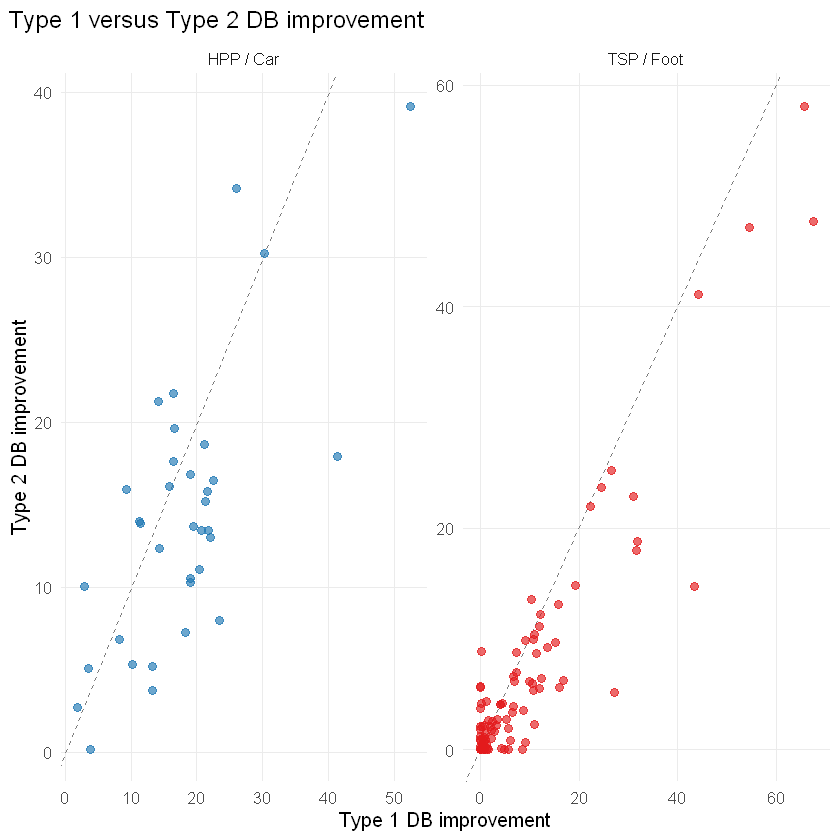

In [312]:
plot_paired_db_scatter <- ggplot(
  paired_route_data,
  aes(x = delta_db_t1, y = delta_db_t2, color = problem_type)
) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "grey50") +
  geom_point(alpha = 0.65, size = 2.2) +
  facet_wrap(~ route_segment, ncol = 2, scales = "free", drop = FALSE) +
  scale_color_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Type 1 versus Type 2 DB improvement",
    x = "Type 1 DB improvement",
    y = "Type 2 DB improvement",
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_paired_db_scatter

### Plot 14: Distribution of Type 2 Minus Type 1 Economic Differences

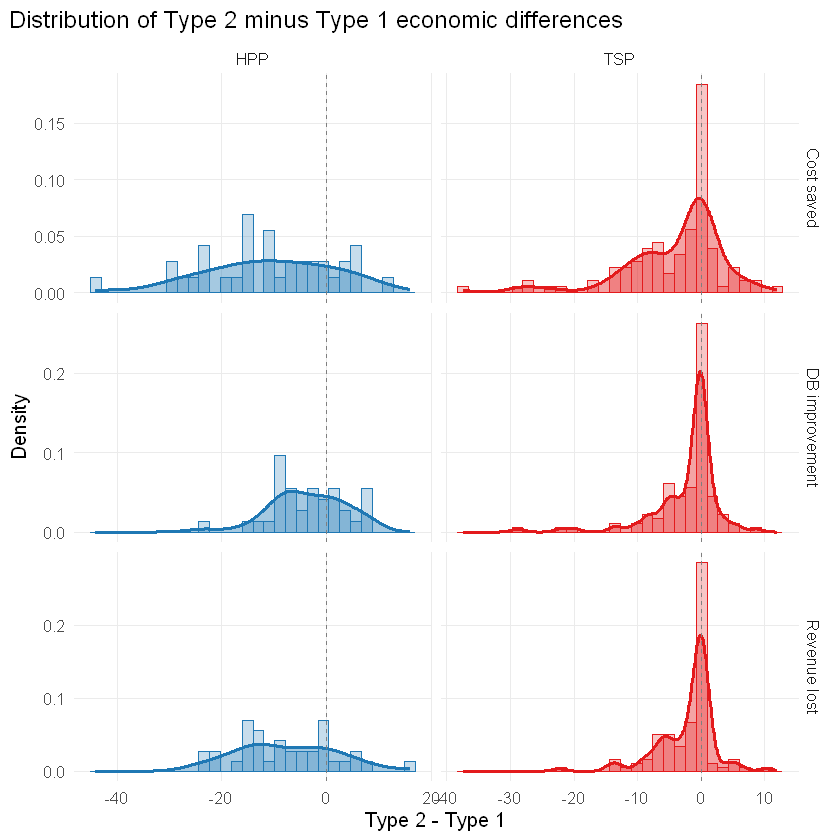

In [313]:
difference_distribution_plot_data <- bind_rows(
  paired_route_data %>% transmute(route_segment, problem_type, metric = "DB improvement", value = delta_db_difference),
  paired_route_data %>% transmute(route_segment, problem_type, metric = "Revenue lost", value = revenue_lost_difference),
  paired_route_data %>% transmute(route_segment, problem_type, metric = "Cost saved", value = cost_saved_difference)
)

plot_difference_distributions <- ggplot(
  difference_distribution_plot_data,
  aes(x = value, fill = problem_type, color = problem_type)
) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, alpha = 0.25, position = "identity") +
  geom_density(linewidth = 0.9, alpha = 0.4, na.rm = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  facet_grid(rows = vars(metric), cols = vars(problem_type), scales = "free", drop = FALSE) +
  scale_fill_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  scale_color_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Distribution of Type 2 minus Type 1 economic differences",
    x = "Type 2 - Type 1",
    y = "Density",
    fill = NULL,
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_difference_distributions

### Plot 15: Economic Differences by Outlier-Set Relation

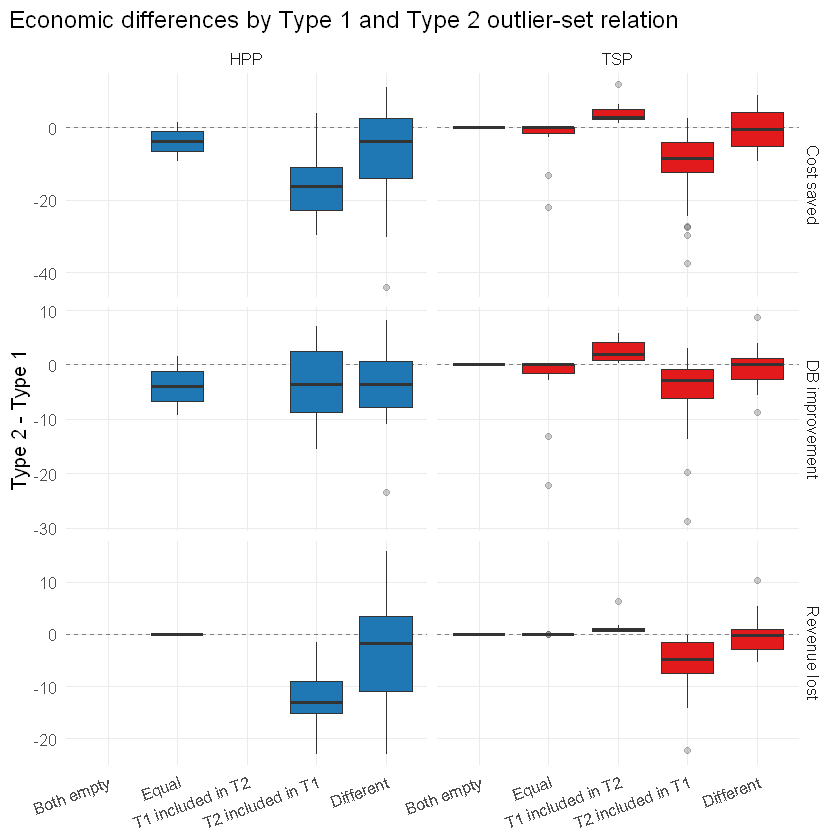

In [314]:
economic_difference_by_relation_plot_data <- bind_rows(
  paired_route_data %>% transmute(route_segment, problem_type, outlier_set_relation, metric = "DB improvement", value = delta_db_difference),
  paired_route_data %>% transmute(route_segment, problem_type, outlier_set_relation, metric = "Revenue lost", value = revenue_lost_difference),
  paired_route_data %>% transmute(route_segment, problem_type, outlier_set_relation, metric = "Cost saved", value = cost_saved_difference)
)

plot_economic_difference_by_relation <- ggplot(
  economic_difference_by_relation_plot_data,
  aes(x = outlier_set_relation, y = value, fill = problem_type)
) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  geom_boxplot(outlier.alpha = 0.25) +
  facet_grid(rows = vars(metric), cols = vars(problem_type), scales = "free_y", drop = FALSE) +
  scale_fill_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Economic differences by Type 1 and Type 2 outlier-set relation",
    x = NULL,
    y = "Type 2 - Type 1",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 20, hjust = 1),
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_economic_difference_by_relation

## 6.7 Characteristics of Routes with Economic Outliers

This section still uses the focused subset with `APR = O18 Omdeler` and `Week Profile = Gns. Oms`.



In [315]:
expand_outlier_positions <- function(data) {
  empty_result <- tibble(
    route_id = character(),
    apr_profile = character(),
    week_profile = character(),
    problem_type = character(),
    route_segment = character(),
    transportform = character(),
    type = character(),
    original_addresses = numeric(),
    address_position = integer(),
    relative_position = numeric()
  )

  if (nrow(data) == 0) {
    return(empty_result)
  }

  expanded_rows <- lapply(seq_len(nrow(data)), function(i) {
    positions <- parse_outlier_set(data$outlier_set_string[[i]])

    if (length(positions) == 0 || is.na(data$original_addresses[[i]]) || data$original_addresses[[i]] <= 0) {
      return(NULL)
    }

    tibble(
      route_id = data$route_id[[i]],
      apr_profile = as.character(data$apr_profile[[i]]),
      week_profile = as.character(data$week_profile[[i]]),
      problem_type = as.character(data$problem_type[[i]]),
      route_segment = as.character(data$route_segment[[i]]),
      transportform = as.character(data$transportform[[i]]),
      type = as.character(data$type[[i]]),
      original_addresses = data$original_addresses[[i]],
      address_position = positions,
      relative_position = positions / data$original_addresses[[i]]
    )
  })

  expanded_result <- bind_rows(expanded_rows)

  if (nrow(expanded_result) == 0) {
    return(empty_result)
  }

  expanded_result
}

section_6_7_route_data <- analysis_data %>%
  mutate(
    outlier_presence = if_else(has_outliers, "With outliers", "Without outliers"),
    revenue_per_address = if_else(original_addresses > 0, revenue_org / original_addresses, NA_real_)
  )

section_6_7_hpp_type1_positions <- expand_outlier_positions(
  analysis_data %>% filter(problem_type == "HPP", type == "Type 1")
) %>%
  mutate(
    position_band = cut(
      relative_position,
      breaks = seq(0, 1, by = 0.1),
      include.lowest = TRUE,
      labels = c(
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50-60%",
        "60-70%",
        "70-80%",
        "80-90%",
        "90-100%"
      )
    )
  )

section_6_7_efficiency_scatter_data <- bind_rows(
  paired_route_data %>%
    transmute(
      type = factor("Type 1", levels = c("Type 1", "Type 2")),
      problem_type,
      route_segment,
      route_efficiency_gap = type2_rel_length_saving,
      removed_outliers = removed_outliers_t1,
      removed_share = if_else(original_addresses > 0, removed_outliers_t1 / original_addresses, NA_real_)
    ),
  paired_route_data %>%
    transmute(
      type = factor("Type 2", levels = c("Type 1", "Type 2")),
      problem_type,
      route_segment,
      route_efficiency_gap = type2_rel_length_saving,
      removed_outliers = removed_outliers_t2,
      removed_share = if_else(original_addresses > 0, removed_outliers_t2 / original_addresses, NA_real_)
    )
)




### Table 14: Route Characteristics With and Without Outliers



In [316]:
section_6_7_route_characteristics_table <- section_6_7_route_data %>%
  group_by(type, outlier_presence) %>%
  summarise(
    route_profiles = n(),
    mean_addresses = mean(original_addresses, na.rm = TRUE),
    median_addresses = median(original_addresses, na.rm = TRUE),
    mean_route_length = mean(length_org, na.rm = TRUE),
    median_route_length = median(length_org, na.rm = TRUE),
    mean_total_revenue = mean(revenue_org, na.rm = TRUE),
    mean_revenue_per_address = mean(revenue_per_address, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    across(
      c(
        mean_addresses,
        median_addresses,
        mean_route_length,
        median_route_length,
        mean_total_revenue,
        mean_revenue_per_address
      ),
      ~ round(.x, 2)
    )
  )

section_6_7_route_characteristics_table %>%
  arrange(type, outlier_presence)



type,outlier_presence,route_profiles,mean_addresses,median_addresses,mean_route_length,median_route_length,mean_total_revenue,mean_revenue_per_address
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Type 1,With outliers,115,111.80,110,4993.33,4982.80,653.50,5.84
Type 1,Without outliers,25,124.08,126,3943.86,3712.80,715.05,5.77
Type 2,With outliers,114,111.78,110,4340.84,4407.75,652.89,5.83
Type 2,Without outliers,26,123.69,122,3339.49,3299.95,715.38,5.80


### Table 15: Composition by Problem Type and Transport Mode



In [317]:
section_6_7_composition_table <- section_6_7_route_data %>%
  count(type, outlier_presence, problem_type, transportform, name = "route_profiles") %>%
  group_by(type, outlier_presence) %>%
  mutate(share_of_group = route_profiles / sum(route_profiles)) %>%
  ungroup() %>%
  mutate(
    transportform = tools::toTitleCase(as.character(transportform)),
    share_of_group = percent(share_of_group, accuracy = 0.1)
  )

section_6_7_composition_table %>%
  arrange(type, outlier_presence, problem_type, transportform)



type,outlier_presence,problem_type,transportform,route_profiles,share_of_group
<fct>,<chr>,<fct>,<chr>,<int>,<chr>
Type 1,With outliers,HPP,Car,35,30.4%
Type 1,With outliers,TSP,Foot,80,69.6%
Type 1,Without outliers,TSP,Foot,25,100.0%
Type 2,With outliers,HPP,Car,35,30.7%
Type 2,With outliers,TSP,Foot,79,69.3%
Type 2,Without outliers,TSP,Foot,26,100.0%


### Plot 16: Route Size, Revenue per Address, and Route Length



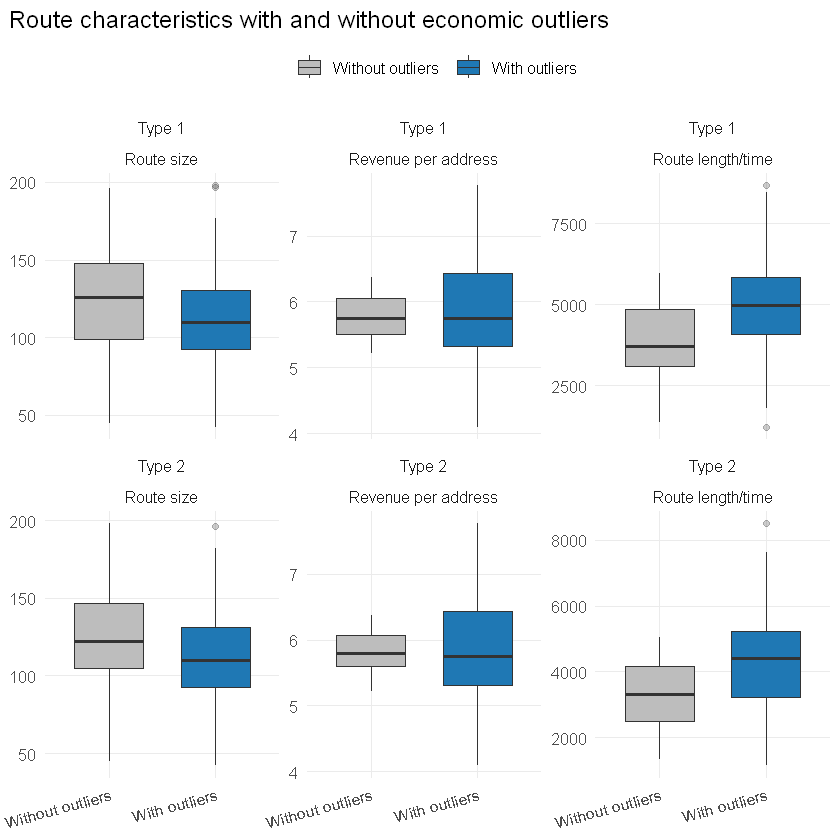

In [318]:
section_6_7_boxplot_data <- bind_rows(
  section_6_7_route_data %>%
    transmute(type, outlier_presence, metric = "Route size", value = original_addresses),
  section_6_7_route_data %>%
    transmute(type, outlier_presence, metric = "Revenue per address", value = revenue_per_address),
  section_6_7_route_data %>%
    transmute(type, outlier_presence, metric = "Route length/time", value = length_org)
) %>%
  mutate(
    metric = factor(metric, levels = c("Route size", "Revenue per address", "Route length/time")),
    outlier_presence = factor(outlier_presence, levels = c("Without outliers", "With outliers"))
  )

plot_route_characteristics_with_vs_without_outliers <- ggplot(
  section_6_7_boxplot_data,
  aes(x = outlier_presence, y = value, fill = outlier_presence)
) +
  geom_boxplot(width = 0.65, outlier.alpha = 0.25) +
  facet_wrap(vars(type, metric), nrow = 2, scales = "free_y") +
  scale_fill_manual(values = c("Without outliers" = "#bdbdbd", "With outliers" = "#1f78b4")) +
  labs(
    title = "Route characteristics with and without economic outliers",
    x = NULL,
    y = NULL,
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot",
    axis.text.x = element_text(angle = 15, hjust = 1)
  )

plot_route_characteristics_with_vs_without_outliers



### Plot 17: Outlier Prevalence by Transport Mode



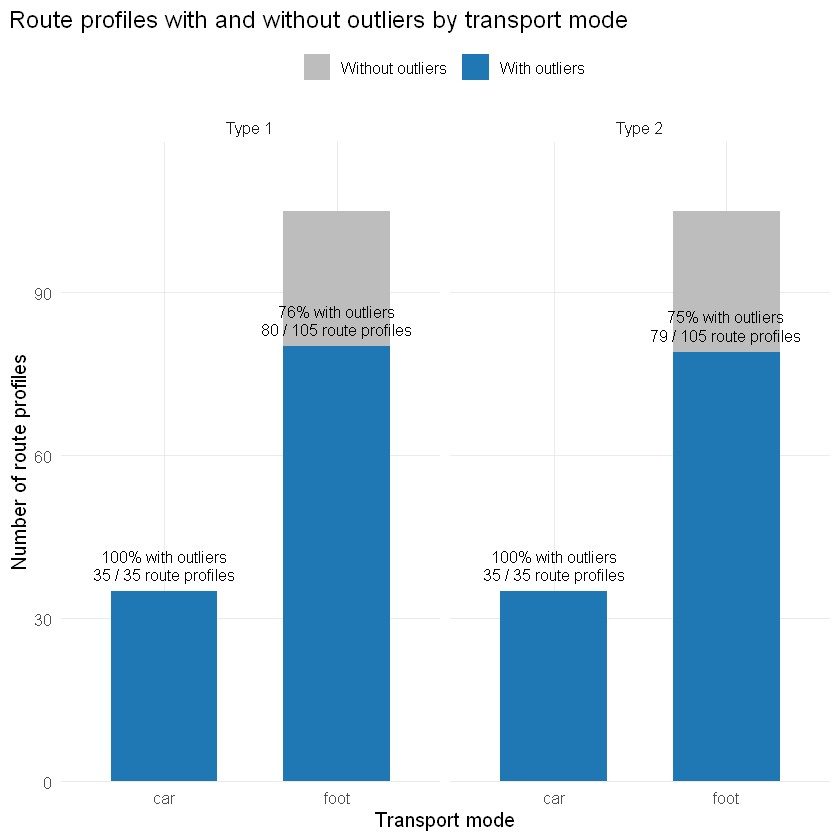

In [319]:
section_6_7_transport_prevalence <- section_6_7_route_data %>%
  count(type, transportform, outlier_presence, name = "route_profiles") %>%
  group_by(type, transportform) %>%
  mutate(
    total_route_profiles = sum(route_profiles),
    share_with_outliers = sum(route_profiles[outlier_presence == "With outliers"]) / total_route_profiles,
    prevalence_label = if_else(
      outlier_presence == "With outliers",
      paste0(
        percent(share_with_outliers, accuracy = 1),
        " with outliers\n",
        route_profiles,
        " / ",
        total_route_profiles,
        " route profiles"
      ),
      NA_character_
    )
  ) %>%
  ungroup() %>%
  mutate(
    transportform = factor(transportform, levels = c("car", "bike", "foot")),
    outlier_presence = factor(outlier_presence, levels = c("Without outliers", "With outliers"))
  )

plot_transport_outlier_prevalence <- ggplot(
  section_6_7_transport_prevalence,
  aes(x = transportform, y = route_profiles, fill = outlier_presence)
) +
  geom_col(width = 0.62) +
  geom_text(
    data = section_6_7_transport_prevalence %>% filter(outlier_presence == "With outliers"),
    aes(label = prevalence_label),
    vjust = -0.35,
    size = 3.4,
    lineheight = 0.95
  ) +
  facet_wrap(~ type) +
  scale_fill_manual(values = c("Without outliers" = "#bdbdbd", "With outliers" = "#1f78b4")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.12))) +
  labs(
    title = "Route profiles with and without outliers by transport mode",
    x = "Transport mode",
    y = "Number of route profiles",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_transport_outlier_prevalence


### Table 16: HPP Type 1 Outlier Positions Along the Original Route



In [320]:
section_6_7_hpp_position_table <- section_6_7_hpp_type1_positions %>%
  mutate(
    position_band = cut(
      relative_position,
      breaks = seq(0, 1, by = 0.1),
      include.lowest = TRUE,
      labels = c(
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50-60%",
        "60-70%",
        "70-80%",
        "80-90%",
        "90-100%"
      )
    )
  ) %>%
  count(position_band, name = "outlier_addresses") %>%
  mutate(
    share_of_hpp_type1_outliers = outlier_addresses / sum(outlier_addresses),
    share_of_hpp_type1_outliers = percent(share_of_hpp_type1_outliers, accuracy = 0.1)
  )

section_6_7_hpp_position_table


position_band,outlier_addresses,share_of_hpp_type1_outliers
<fct>,<int>,<chr>
0-10%,14,11.1%
10-20%,7,5.6%
20-30%,14,11.1%
30-40%,9,7.1%
40-50%,9,7.1%
50-60%,10,7.9%
60-70%,7,5.6%
70-80%,23,18.3%
80-90%,9,7.1%


### Plot 18: Relative Sequence Position of HPP Type 1 Outliers



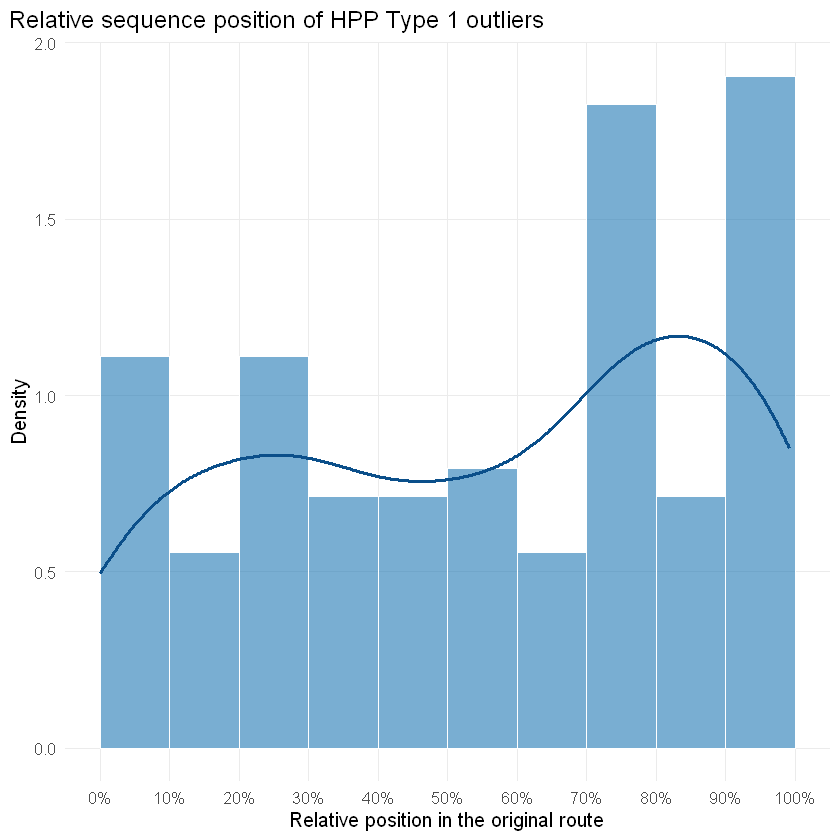

In [321]:
plot_hpp_type1_relative_position <- ggplot(
  section_6_7_hpp_type1_positions,
  aes(x = relative_position)
) +
  geom_histogram(
    aes(y = after_stat(density)),
    binwidth = 0.1,
    boundary = 0,
    fill = "#1f78b4",
    alpha = 0.6,
    color = "white"
  ) +
  geom_density(color = "#0b4f8a", linewidth = 1) +
  scale_x_continuous(
    breaks = seq(0, 1, by = 0.1),
    labels = percent_format(accuracy = 1)
  ) +
  labs(
    title = "Relative sequence position of HPP Type 1 outliers",
    x = "Relative position in the original route",
    y = "Density"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_hpp_type1_relative_position


### Plot 19: Route-Efficiency Gap Versus Outlier Prevalence



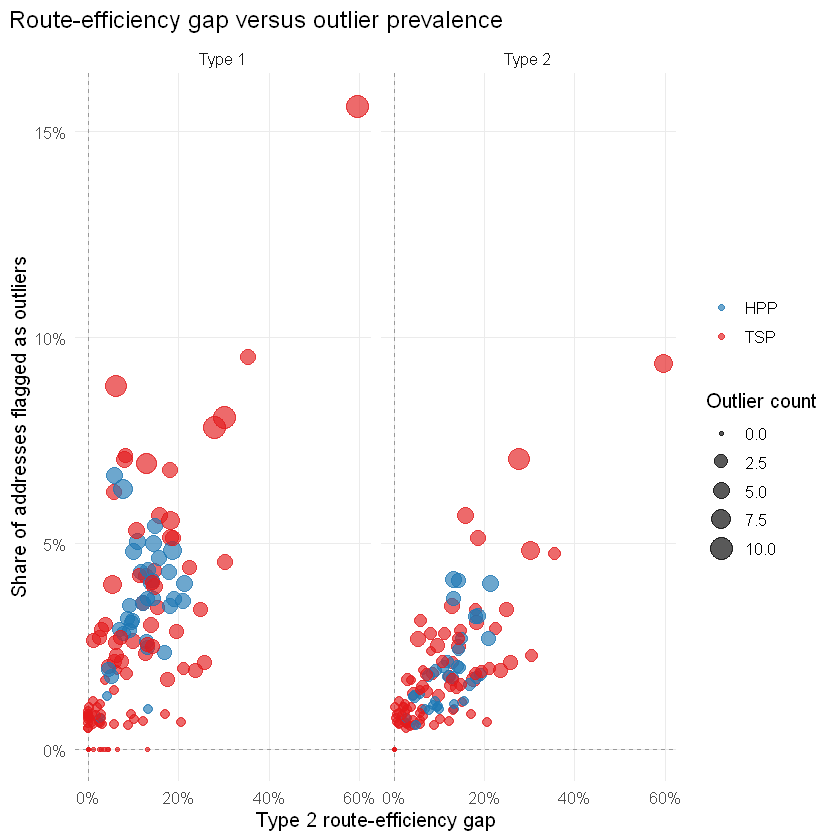

In [322]:
plot_efficiency_gap_vs_outliers <- ggplot(
  section_6_7_efficiency_scatter_data,
  aes(x = route_efficiency_gap, y = removed_share, size = removed_outliers, color = problem_type)
) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey60") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey60") +
  geom_point(alpha = 0.65) +
  facet_wrap(~ type) +
  scale_x_continuous(labels = percent_format(accuracy = 1)) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_color_manual(values = c("HPP" = "#1f78b4", "TSP" = "#e31a1c")) +
  labs(
    title = "Route-efficiency gap versus outlier prevalence",
    x = "Type 2 route-efficiency gap",
    y = "Share of addresses flagged as outliers",
    color = NULL,
    size = "Outlier count"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "right",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_efficiency_gap_vs_outliers



## 6.8 Sensitivity to Economic Assumptions

APR sensitivity is evaluated at fixed `Week Profile = Gns. Oms`, while week-profile sensitivity is evaluated at fixed `APR = O18 Omdeler`.



### 6.8A APR Sensitivity



In [323]:
section_6_8_apr_summary_table <- apr_sensitivity_data %>%
  group_by(route_segment, apr_profile, type) %>%
  summarise(
    route_profiles = n(),
    routes_without_outliers = sum(!has_outliers, na.rm = TRUE),
    share_without_outliers = routes_without_outliers / route_profiles,
    routes_with_outliers = sum(has_outliers, na.rm = TRUE),
    share_with_outliers = routes_with_outliers / route_profiles,
    outlier_addresses = sum(removed_outliers, na.rm = TRUE),
    outlier_rate = outlier_addresses / sum(original_addresses, na.rm = TRUE),
    mean_outliers_per_route = mean(removed_outliers, na.rm = TRUE),
    revenue_lost = sum(revenue_lost, na.rm = TRUE),
    cost_saved = sum(cost_saved, na.rm = TRUE),
    db_improvement = sum(delta_db, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    share_without_outliers = percent(share_without_outliers, accuracy = 0.1),
    share_with_outliers = percent(share_with_outliers, accuracy = 0.1),
    outlier_rate = percent(outlier_rate, accuracy = 0.1),
    mean_outliers_per_route = round(mean_outliers_per_route, 2),
    revenue_lost = round(revenue_lost, 2),
    cost_saved = round(cost_saved, 2),
    db_improvement = round(db_improvement, 2)
  )

section_6_8_apr_transition_table <- apr_sensitivity_data %>%
  arrange(route_segment, type, route_id, apr_profile) %>%
  group_by(route_segment, type, route_id) %>%
  summarise(
    classification_pattern = paste(
      paste0(as.character(apr_profile), ": ", if_else(has_outliers, "Outlier", "No outlier")),
      collapse = " | "
    ),
    .groups = "drop"
  ) %>%
  count(route_segment, type, classification_pattern, name = "route_profiles") %>%
  group_by(route_segment, type) %>%
  mutate(share_of_routes = percent(route_profiles / sum(route_profiles), accuracy = 0.1)) %>%
  ungroup()

section_6_8_apr_address_records <- expand_outlier_positions(apr_sensitivity_data)

section_6_8_apr_address_stability_table <- section_6_8_apr_address_records %>%
  group_by(route_segment, type, route_id, address_position) %>%
  summarise(detected_in_apr_profiles = n_distinct(apr_profile), .groups = "drop") %>%
  count(route_segment, type, detected_in_apr_profiles, name = "outlier_addresses") %>%
  group_by(route_segment, type) %>%
  mutate(share_of_outlier_addresses = percent(outlier_addresses / sum(outlier_addresses), accuracy = 0.1)) %>%
  ungroup()

section_6_8_apr_economic_plot_data <- bind_rows(
  apr_sensitivity_data %>%
    group_by(route_segment, apr_profile, type) %>%
    summarise(metric = "Revenue lost", value = mean(revenue_lost, na.rm = TRUE), .groups = "drop"),
  apr_sensitivity_data %>%
    group_by(route_segment, apr_profile, type) %>%
    summarise(metric = "Cost saved", value = mean(cost_saved, na.rm = TRUE), .groups = "drop"),
  apr_sensitivity_data %>%
    group_by(route_segment, apr_profile, type) %>%
    summarise(metric = "DB improvement", value = mean(delta_db, na.rm = TRUE), .groups = "drop")
) %>%
  mutate(metric = factor(metric, levels = c("Revenue lost", "Cost saved", "DB improvement")))



### Table 17: APR Sensitivity Summary



In [324]:
section_6_8_apr_summary_table %>%
  arrange(route_segment, apr_profile, type)



route_segment,apr_profile,type,route_profiles,routes_without_outliers,share_without_outliers,routes_with_outliers,share_with_outliers,outlier_addresses,outlier_rate,mean_outliers_per_route,revenue_lost,cost_saved,db_improvement
<fct>,<fct>,<fct>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
HPP / Car,SE Omdeler,Type 1,35,0,0.0%,35,100.0%,207,5.7%,5.91,1259.89,3266.15,2006.21
HPP / Car,SE Omdeler,Type 2,35,0,0.0%,35,100.0%,139,3.8%,3.97,808.56,2261.12,1452.55
HPP / Car,O18 Omdeler,Type 1,35,0,0.0%,35,100.0%,126,3.5%,3.60,608.21,1230.85,622.64
HPP / Car,O18 Omdeler,Type 2,35,0,0.0%,35,100.0%,68,1.9%,1.94,347.94,844.95,496.82
TSP / Foot,SE Omdeler,Type 1,105,8,7.6%,97,92.4%,402,3.3%,3.83,1476.74,4100.65,2623.96
TSP / Foot,SE Omdeler,Type 2,105,8,7.6%,97,92.4%,281,2.3%,2.68,1091.89,3064.13,1972.54
TSP / Foot,O18 Omdeler,Type 1,105,25,23.8%,80,76.2%,229,1.9%,2.18,638.05,1497.65,859.67
TSP / Foot,O18 Omdeler,Type 2,105,26,24.8%,79,75.2%,150,1.2%,1.43,419.49,1055.50,635.81
TSP / Foot,U18 Omdeler,Type 1,105,31,29.5%,74,70.5%,164,1.3%,1.56,390.12,840.47,450.40


### Table 18: Route Classification Transitions Across APR Profiles



In [325]:
section_6_8_apr_transition_table %>%
  arrange(route_segment, type, desc(route_profiles))



route_segment,type,classification_pattern,route_profiles,share_of_routes
<fct>,<fct>,<chr>,<int>,<chr>
HPP / Car,Type 1,SE Omdeler: Outlier | O18 Omdeler: Outlier,35,100.0%
HPP / Car,Type 2,SE Omdeler: Outlier | O18 Omdeler: Outlier,35,100.0%
TSP / Foot,Type 1,SE Omdeler: Outlier | O18 Omdeler: Outlier | U18 Omdeler: Outlier,74,70.5%
TSP / Foot,Type 1,SE Omdeler: Outlier | O18 Omdeler: No outlier | U18 Omdeler: No outlier,17,16.2%
TSP / Foot,Type 1,SE Omdeler: No outlier | O18 Omdeler: No outlier | U18 Omdeler: No outlier,8,7.6%
TSP / Foot,Type 1,SE Omdeler: Outlier | O18 Omdeler: Outlier | U18 Omdeler: No outlier,6,5.7%
TSP / Foot,Type 2,SE Omdeler: Outlier | O18 Omdeler: Outlier | U18 Omdeler: Outlier,70,66.7%
TSP / Foot,Type 2,SE Omdeler: Outlier | O18 Omdeler: No outlier | U18 Omdeler: No outlier,18,17.1%
TSP / Foot,Type 2,SE Omdeler: Outlier | O18 Omdeler: Outlier | U18 Omdeler: No outlier,9,8.6%


### Table 19: Address Stability Across APR Profiles



In [326]:
section_6_8_apr_address_stability_table %>%
  arrange(route_segment, type, detected_in_apr_profiles)



route_segment,type,detected_in_apr_profiles,outlier_addresses,share_of_outlier_addresses
<chr>,<chr>,<int>,<int>,<chr>
HPP / Car,Type 1,1,129,55.8%
HPP / Car,Type 1,2,102,44.2%
HPP / Car,Type 2,1,111,69.8%
HPP / Car,Type 2,2,48,30.2%
TSP / Foot,Type 1,1,193,46.0%
TSP / Foot,Type 1,2,79,18.8%
TSP / Foot,Type 1,3,148,35.2%
TSP / Foot,Type 2,1,163,52.6%
TSP / Foot,Type 2,2,64,20.6%


### Plot 20: Outlier Rate by APR Profile


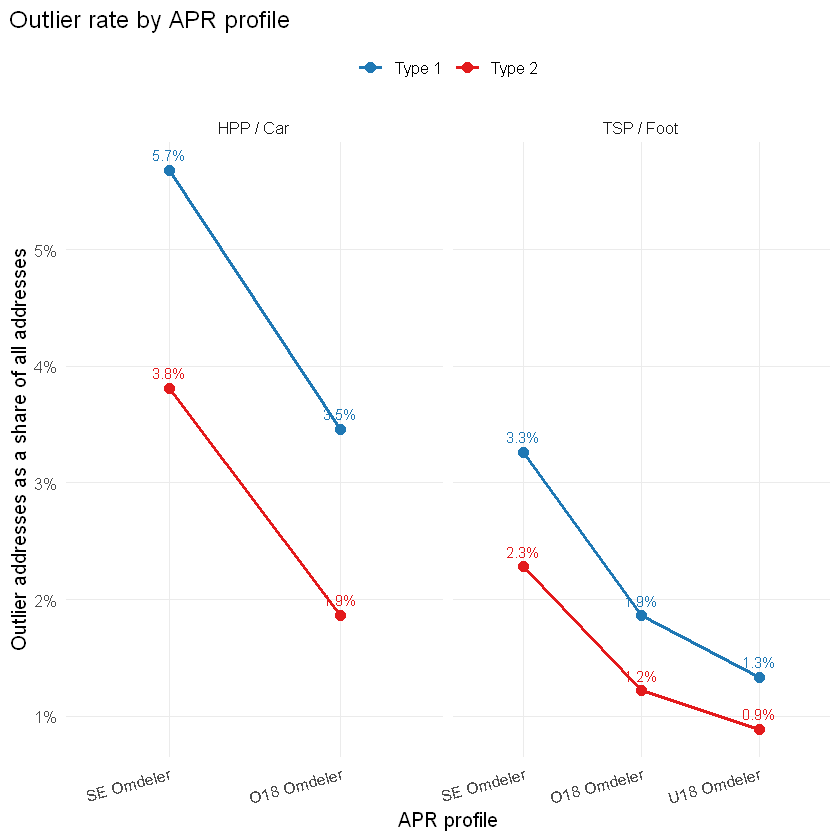

In [327]:
plot_apr_share_with_outliers <- apr_sensitivity_data %>%
  group_by(route_segment, apr_profile, type) %>%
  summarise(
    outlier_rate = sum(removed_outliers, na.rm = TRUE) / sum(original_addresses, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = apr_profile, y = outlier_rate, color = type, group = type)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.8) +
  geom_text(
    aes(label = percent(outlier_rate, accuracy = 0.1)),
    vjust = -0.8,
    size = 3.2,
    show.legend = FALSE
  ) +
  facet_wrap(~ route_segment, scales = "free_x", drop = FALSE) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_color_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Outlier rate by APR profile",
    x = "APR profile",
    y = "Outlier addresses as a share of all addresses",
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot",
    axis.text.x = element_text(angle = 15, hjust = 1)
  )

plot_apr_share_with_outliers


### Plot 21: Mean Number of Outliers per Route by APR Profile



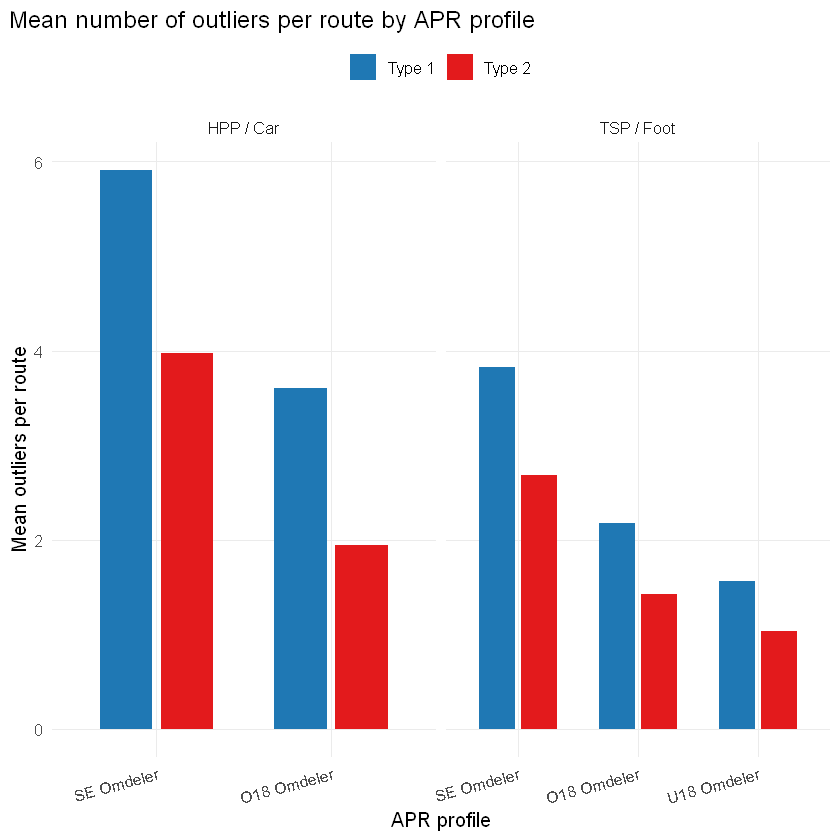

In [328]:
plot_apr_mean_outliers <- ggplot(
  section_6_8_apr_summary_table,
  aes(x = apr_profile, y = mean_outliers_per_route, fill = type)
) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ route_segment, scales = "free_x", drop = FALSE) +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Mean number of outliers per route by APR profile",
    x = "APR profile",
    y = "Mean outliers per route",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot",
    axis.text.x = element_text(angle = 15, hjust = 1)
  )

plot_apr_mean_outliers



### Plot 22: Mean Economic Impact per Route by APR Profile



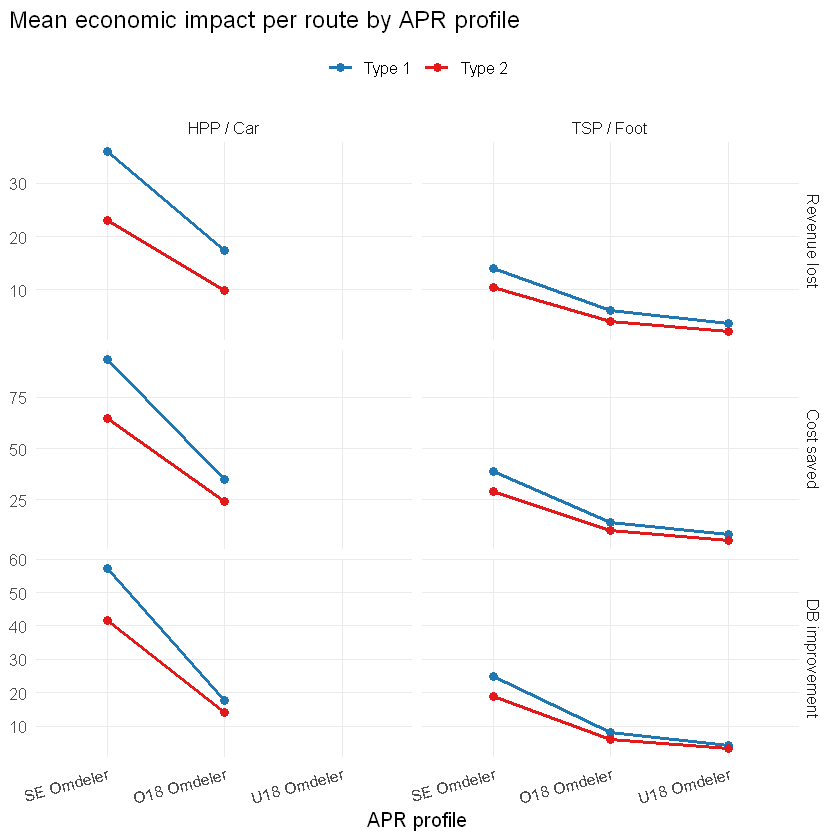

In [329]:
plot_apr_economic_impact <- ggplot(
  section_6_8_apr_economic_plot_data,
  aes(x = apr_profile, y = value, color = type, group = type)
) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2.2) +
  facet_grid(metric ~ route_segment, scales = "free_y") +
  scale_color_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Mean economic impact per route by APR profile",
    x = "APR profile",
    y = NULL,
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot",
    axis.text.x = element_text(angle = 15, hjust = 1)
  )

plot_apr_economic_impact



### Plot 23: Stability of Outlier Addresses Across APR Profiles



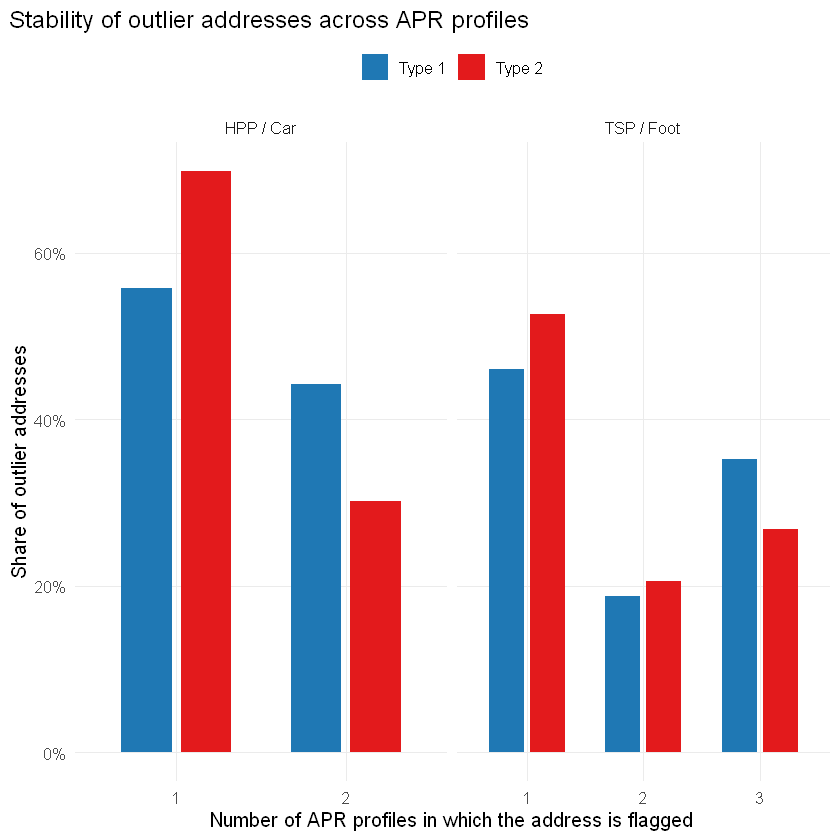

In [330]:
plot_apr_address_stability <- ggplot(
  section_6_8_apr_address_stability_table,
  aes(x = factor(detected_in_apr_profiles), y = parse_number(share_of_outlier_addresses) / 100, fill = type)
) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ route_segment, scales = "free_x", drop = FALSE) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Stability of outlier addresses across APR profiles",
    x = "Number of APR profiles in which the address is flagged",
    y = "Share of outlier addresses",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_apr_address_stability



### 6.8B Revenue-Profile Sensitivity



In [331]:
section_6_8_week_summary_table <- week_sensitivity_data %>%
  group_by(route_segment, week_profile, type) %>%
  summarise(
    route_profiles = n(),
    routes_without_outliers = sum(!has_outliers, na.rm = TRUE),
    share_without_outliers = routes_without_outliers / route_profiles,
    routes_with_outliers = sum(has_outliers, na.rm = TRUE),
    share_with_outliers = routes_with_outliers / route_profiles,
    outlier_addresses = sum(removed_outliers, na.rm = TRUE),
    outlier_rate = outlier_addresses / sum(original_addresses, na.rm = TRUE),
    mean_outliers_per_route = mean(removed_outliers, na.rm = TRUE),
    revenue_lost = sum(revenue_lost, na.rm = TRUE),
    cost_saved = sum(cost_saved, na.rm = TRUE),
    db_improvement = sum(delta_db, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    share_without_outliers = percent(share_without_outliers, accuracy = 0.1),
    share_with_outliers = percent(share_with_outliers, accuracy = 0.1),
    outlier_rate = percent(outlier_rate, accuracy = 0.1),
    mean_outliers_per_route = round(mean_outliers_per_route, 2),
    revenue_lost = round(revenue_lost, 2),
    cost_saved = round(cost_saved, 2),
    db_improvement = round(db_improvement, 2)
  )

section_6_8_week_address_records <- expand_outlier_positions(observed_week_sensitivity_data)

section_6_8_week_address_stability_table <- section_6_8_week_address_records %>%
  group_by(route_segment, type, route_id, address_position) %>%
  summarise(detected_in_weeks = n_distinct(week_profile), .groups = "drop") %>%
  count(route_segment, type, detected_in_weeks, name = "outlier_addresses") %>%
  group_by(route_segment, type) %>%
  mutate(share_of_outlier_addresses = percent(outlier_addresses / sum(outlier_addresses), accuracy = 0.1)) %>%
  ungroup()

section_6_8_heatmap_data <- observed_week_sensitivity_data %>%
  mutate(
    week_profile = factor(as.character(week_profile), levels = c("U36", "U37", "U38", "U39")),
    outlier_bucket = case_when(
      removed_outliers >= 6 ~ "6+",
      TRUE ~ as.character(removed_outliers)
    ),
    outlier_bucket = factor(outlier_bucket, levels = c("0", "1", "2", "3", "4", "5", "6+"))
  ) %>%
  count(route_segment, type, week_profile, outlier_bucket, name = "route_profiles") %>%
  group_by(route_segment, type, week_profile) %>%
  mutate(share_of_routes = route_profiles / sum(route_profiles)) %>%
  ungroup()


### Table 20: Week-Profile Sensitivity Summary



In [332]:
section_6_8_week_summary_table %>%
  arrange(route_segment, week_profile, type)



route_segment,week_profile,type,route_profiles,routes_without_outliers,share_without_outliers,routes_with_outliers,share_with_outliers,outlier_addresses,outlier_rate,mean_outliers_per_route,revenue_lost,cost_saved,db_improvement
<fct>,<fct>,<fct>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
HPP / Car,Gns. Oms,Type 1,35,0,0.0%,35,100.0%,126,3.5%,3.60,608.21,1230.85,622.64
HPP / Car,Gns. Oms,Type 2,35,0,0.0%,35,100.0%,68,1.9%,1.94,347.94,844.95,496.82
HPP / Car,U36,Type 1,35,0,0.0%,35,100.0%,127,3.5%,3.63,584.54,1209.58,625.01
HPP / Car,U36,Type 2,35,0,0.0%,35,100.0%,68,1.9%,1.94,326.77,828.33,501.38
HPP / Car,U37,Type 1,35,0,0.0%,35,100.0%,141,3.9%,4.03,620.78,1336.79,716.03
HPP / Car,U37,Type 2,35,0,0.0%,35,100.0%,76,2.1%,2.17,317.51,878.37,560.62
HPP / Car,U38,Type 1,35,0,0.0%,35,100.0%,127,3.5%,3.63,571.52,1230.96,659.43
HPP / Car,U38,Type 2,35,0,0.0%,35,100.0%,67,1.8%,1.91,299.34,812.55,513.02
HPP / Car,U39,Type 1,35,1,2.9%,34,97.1%,114,3.1%,3.26,617.33,1156.42,539.08


### Table 21: Address Stability Across Observed Weeks



In [333]:
section_6_8_week_address_stability_table %>%
  arrange(route_segment, type, detected_in_weeks)



route_segment,type,detected_in_weeks,outlier_addresses,share_of_outlier_addresses
<chr>,<chr>,<int>,<int>,<chr>
HPP / Car,Type 1,1,30,18.0%
HPP / Car,Type 1,2,25,15.0%
HPP / Car,Type 1,3,19,11.4%
HPP / Car,Type 1,4,93,55.7%
HPP / Car,Type 2,1,17,18.1%
HPP / Car,Type 2,2,16,17.0%
HPP / Car,Type 2,3,18,19.1%
HPP / Car,Type 2,4,43,45.7%
TSP / Foot,Type 1,1,144,30.6%


### Plot 24: Outlier Rate by Week Profile


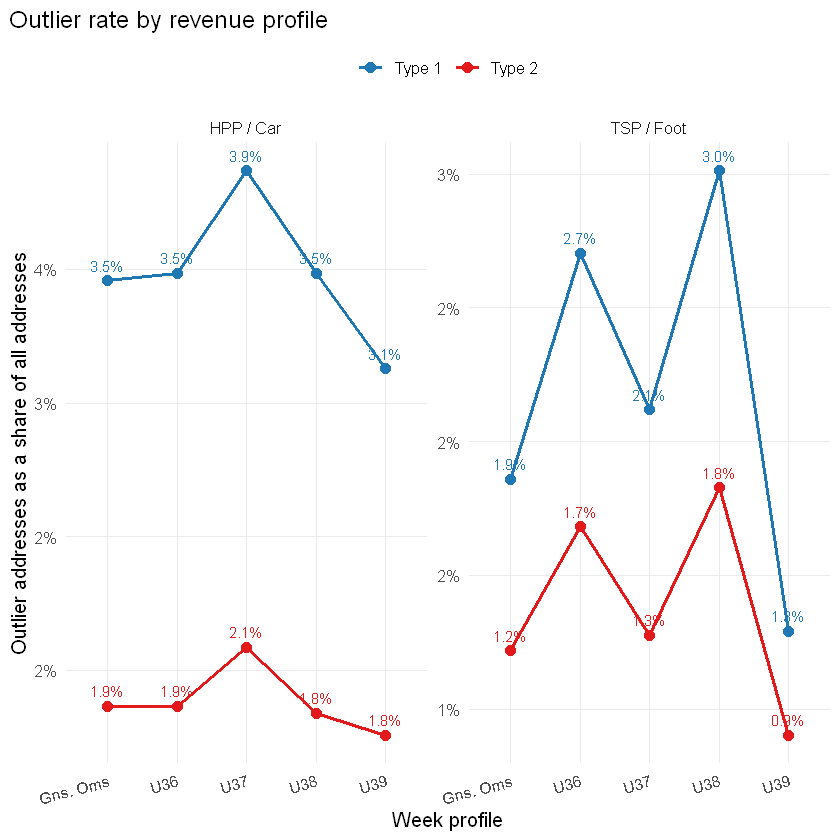

In [334]:
plot_week_share_with_outliers <- week_sensitivity_data %>%
  group_by(route_segment, week_profile, type) %>%
  summarise(
    outlier_rate = sum(removed_outliers, na.rm = TRUE) / sum(original_addresses, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = week_profile, y = outlier_rate, color = type, group = type)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.8) +
  geom_text(
    aes(label = percent(outlier_rate, accuracy = 0.1)),
    vjust = -0.8,
    size = 3.1,
    show.legend = FALSE
  ) +
  facet_wrap(~ route_segment, scales = "free_y", drop = FALSE) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_color_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Outlier rate by revenue profile",
    x = "Week profile",
    y = "Outlier addresses as a share of all addresses",
    color = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot",
    axis.text.x = element_text(angle = 15, hjust = 1)
  )

plot_week_share_with_outliers


### Plot 25: Mean Number of Outliers per Route by Week Profile



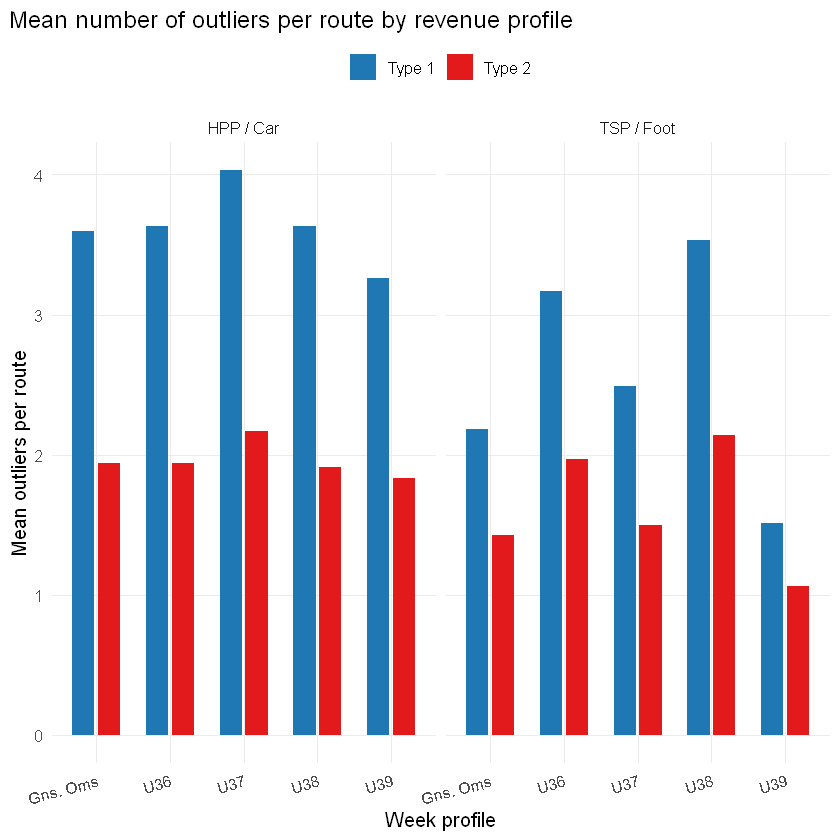

In [335]:
plot_week_mean_outliers <- ggplot(
  section_6_8_week_summary_table,
  aes(x = week_profile, y = mean_outliers_per_route, fill = type)
) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ route_segment, scales = "free_x", drop = FALSE) +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Mean number of outliers per route by revenue profile",
    x = "Week profile",
    y = "Mean outliers per route",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot",
    axis.text.x = element_text(angle = 15, hjust = 1)
  )

plot_week_mean_outliers



### Plot 26: Distribution of Outlier Counts Across Weeks


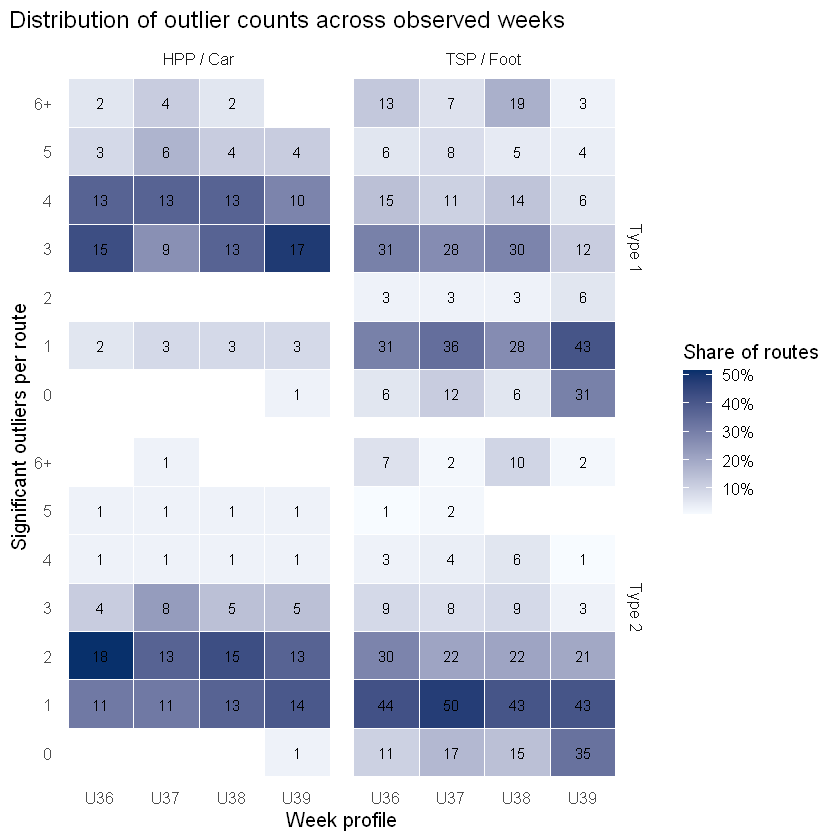

In [337]:
plot_route_week_heatmap <- ggplot(
  section_6_8_heatmap_data,
  aes(x = week_profile, y = outlier_bucket, fill = share_of_routes)
) +
  geom_tile(color = "white", linewidth = 0.35) +
  geom_text(
    aes(label = if_else(route_profiles > 0, as.character(route_profiles), "")),
    size = 3.1
  ) +
  facet_grid(type ~ route_segment) +
  scale_fill_gradient(low = "#f7fbff", high = "#08306b", labels = percent_format(accuracy = 1)) +
  labs(
    title = "Distribution of outlier counts across observed weeks",
    x = "Week profile",
    y = "Significant outliers per route",
    fill = "Share of routes"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    plot.title.position = "plot"
  )

plot_route_week_heatmap


### Plot 27: Stability of Outlier Addresses Across Observed Weeks



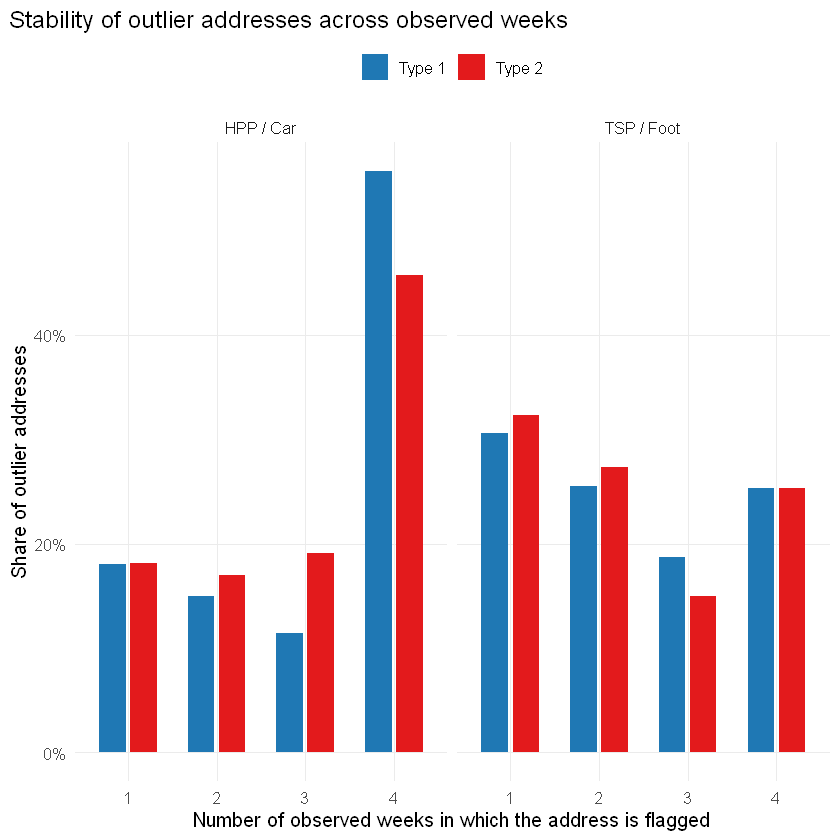

In [338]:
plot_week_address_stability <- ggplot(
  section_6_8_week_address_stability_table,
  aes(x = factor(detected_in_weeks), y = parse_number(share_of_outlier_addresses) / 100, fill = type)
) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ route_segment, scales = "free_x", drop = FALSE) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("Type 1" = "#1f78b4", "Type 2" = "#e31a1c")) +
  labs(
    title = "Stability of outlier addresses across observed weeks",
    x = "Number of observed weeks in which the address is flagged",
    y = "Share of outlier addresses",
    fill = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.minor = element_blank(),
    plot.title.position = "plot"
  )

plot_week_address_stability



## Next Step

The notebook now covers Sections 6.3 to 6.8. The next natural step is to add short written interpretations below the main tables and plots, and then decide which comparisons are strong enough to take forward into formal hypothesis tests.

